<a href="https://colab.research.google.com/github/shardeep-x/agentic-ai-and-gen-ai/blob/main/IMDB_Sentiment_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis: From Bag-of-Words to Neural Classifiers

---

> ### 📋 Assignment
> You will build a complete sentiment classification pipeline on the **IMDB Movie Review** dataset — 50,000 reviews labelled positive or negative.
>
> **Part 1** uses classical machine learning on **binary one-hot vectors** — the simplest possible text representation.
> **Part 2** introduces neural sequence models for NLP. The boilerplate (data loading, vocabulary, training loop, evaluation) is **fully provided and pre-written**. Your job is to:
> 1. Build the **model architectures** (`### CODE HERE ###` inside `nn.Module` classes)
> 2. Write **interpretation and reflection** cells
>
> **Cells marked `# ── PROVIDED ──` carry no marks** — just run them.
> **Cells marked `### CODE HERE ###` carry marks** — these are yours to complete.
>
> Use `random_state=42` wherever accepted.

---

## What You Will Build

| Part | Approach | Key Idea |
|------|----------|----------|
| **Part 1** | Classical ML — LR, Naive Bayes, SVM, Random Forest | Binary one-hot vectors (word present/absent) |
| **Part 2A** | Vanilla RNN | Reads tokens sequentially; hidden state carries context |
| **Part 2B** | LSTM | Gated memory solves long-range forgetting |
| **Part 2C** | Bidirectional LSTM + FastText embeddings | Both-direction context + pre-trained word meaning |
| **Part 2D** | Cross-Attention Classifier | Every token attends to every other — no sequential bottleneck |

**Total Marks: 100** (Part 1: 45 | Part 2: 55)

### The Central Question
> *Can a model reading `"the film is not as bad as critics claimed"` correctly identify it as **positive**?*
>
> A one-hot vector sees `bad` and `critics` as present — and guesses *negative*. A neural model reading the full sentence in order has a fighting chance. An attention model can show you exactly which words it focused on.

---

# PART 1: Classical Sentiment Classification

## Context

The IMDB dataset contains 50,000 movie reviews — 25,000 for training, 25,000 for testing, perfectly balanced between positive and negative.

Reviews average **~230 words** — long enough that word order and negation genuinely matter. In this part, you will represent each review as a **binary one-hot vector**: a vector of 0s and 1s where a 1 simply means a word appeared in the review, and 0 means it did not. Frequency is ignored entirely — `"masterpiece"` appearing once and `"bad"` appearing ten times both become 1.

This is intentionally the simplest possible text representation. It sets a realistic ceiling that the neural models in Part 2 need to meaningfully exceed. You will see exactly where this representation breaks down.

## Stage 1: Data Loading  <font color="red">**[4 marks]**</font>

**What to do:**
- The libraries below are pre-imported. Add anything else you need.
- Load the IMDB dataset using `load_dataset('imdb')` from HuggingFace.
- Extract train texts, test texts, and their labels into plain Python lists.
- Print the number of examples and class distribution.

In [35]:
pip install --upgrade datasets huggingface_hub

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [37]:
# Import necessary library for dataset loading directly within this cell.
from datasets import load_dataset

# Load the IMDB dataset from HuggingFace's datasets library.
# The 'imdb' dataset is a well-known dataset. The HfUriError about 'namespace/name'
# indicates a potential issue with how the library resolves dataset names in this environment.
# Attempting to load with `token=True` to address potential authentication/resolution issues.
dataset = load_dataset('stanfordnlp/imdb')

# Extract training texts (movie reviews) and their corresponding sentiment labels
train_texts  = dataset['train']['text']
train_labels = dataset['train']['label']

# Extract testing texts and their corresponding sentiment labels
test_texts   = dataset['test']['text']
test_labels  = dataset['test']['label']

# Convert the integer labels (0 for negative, 1 for positive) to numpy arrays
# for consistency and easier numerical operations with libraries like scikit-learn.
y_train = np.array(train_labels)
y_test  = np.array(test_labels)

In [38]:
# Print the total number of examples (reviews) in the training set
print(f"Training examples: {len(train_texts)}")
# Print the total number of examples (reviews) in the testing set
print(f"Testing examples: {len(test_texts)}")

# Print the distribution of labels (0 for negative, 1 for positive) in the training set
print("\nTraining label distribution:")
print(pd.Series(train_labels).value_counts(normalize=True))

# Print the distribution of labels in the testing set
print("\nTesting label distribution:")
print(pd.Series(test_labels).value_counts(normalize=True))

Training examples: 25000
Testing examples: 25000

Training label distribution:
0    0.5
1    0.5
Name: proportion, dtype: float64

Testing label distribution:
0    0.5
1    0.5
Name: proportion, dtype: float64


## Stage 2: Data Understanding  <font color="red">**[8 marks]**</font>

### 2.1 Class Distribution  <font color="red">[1 mark]</font>

Plot a bar chart of positive vs negative counts in the training set.

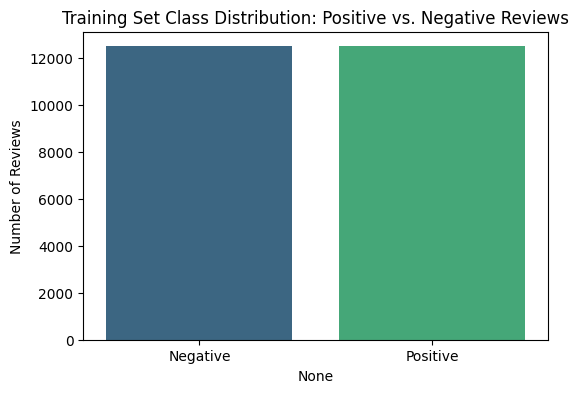

Class Distribution in Training Set:
0    12500
1    12500
Name: count, dtype: int64


In [39]:
# Import necessary libraries for data manipulation and plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the counts of positive (1) and negative (0) reviews in the training set
# pd.Series is used to easily apply value_counts() to the list of labels.
label_counts = pd.Series(train_labels).value_counts()

# Create a bar plot to visualize the class distribution
plt.figure(figsize=(6, 4)) # Set the figure size for better visualization
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')

# Set x-axis labels to 'Negative' and 'Positive' for better readability
# The ticks correspond to the label values (0 and 1).
plt.xticks(ticks=[0, 1], labels=['Negative', 'Positive'])

# Add a title to the plot to describe its content
plt.title('Training Set Class Distribution: Positive vs. Negative Reviews')

# Label the y-axis as 'Number of Reviews' to indicate what the bars represent
plt.ylabel('Number of Reviews')

# Display the plot
plt.show()

# Print the numerical counts for clarity, showing exact numbers for each class
print("Class Distribution in Training Set:")
print(label_counts)

### 2.2 Review Length Distribution  <font color="red">[2 marks]</font>

Compute word count per training review. Plot a histogram and print the mean, median, and 95th percentile length.
Also plot lengths **separately for positive and negative reviews** using overlapping histograms.

Review Length Distribution (Training Set):
  Mean: 233.79 words
  Median: 174 words
  95th percentile: 598 words


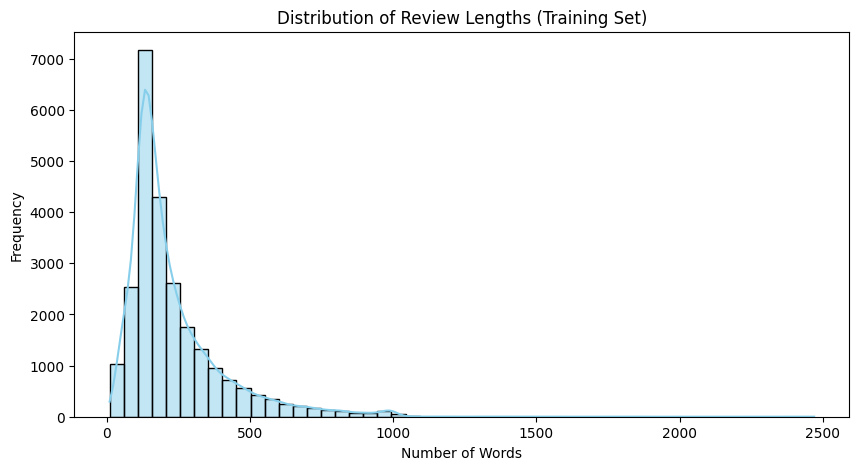

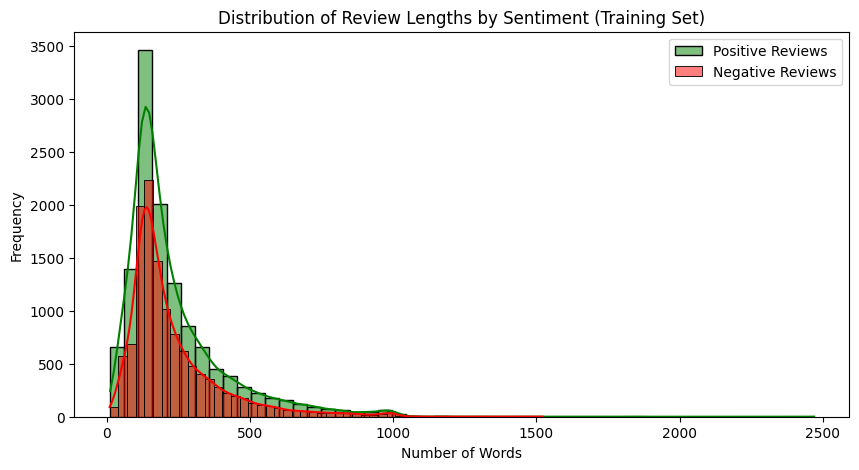

In [40]:
# Calculate word count for each training review
# Split each text by spaces and count the resulting words
train_word_counts = [len(text.split()) for text in train_texts]

# Convert to a Pandas Series for easier statistical calculations
word_counts_series = pd.Series(train_word_counts)

# Print mean, median, and 95th percentile of word counts
print("Review Length Distribution (Training Set):")
print(f"  Mean: {word_counts_series.mean():.2f} words")
print(f"  Median: {word_counts_series.median():.0f} words")
print(f"  95th percentile: {word_counts_series.quantile(0.95):.0f} words")

# Plot a histogram of review lengths
plt.figure(figsize=(10, 5))
sns.histplot(word_counts_series, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Lengths (Training Set)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Separate word counts for positive and negative reviews
positive_word_counts = [len(text.split()) for text, label in zip(train_texts, train_labels) if label == 1]
negative_word_counts = [len(text.split()) for text, label in zip(train_texts, train_labels) if label == 0]

# Plot overlapping histograms for positive and negative review lengths
plt.figure(figsize=(10, 5))
sns.histplot(positive_word_counts, bins=50, color='green', label='Positive Reviews', kde=True, alpha=0.5)
sns.histplot(negative_word_counts, bins=50, color='red', label='Negative Reviews', kde=True, alpha=0.5)
plt.title('Distribution of Review Lengths by Sentiment (Training Set)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### 2.3 Sample Reviews  <font color="red">[1 mark]</font>

Print the first 200 characters of one positive and one negative review. Note any HTML artefacts you see.

In [41]:
# Find the index of the first positive review (label == 1)
positive_index = next(i for i, label in enumerate(train_labels) if label == 1)
# Find the index of the first negative review (label == 0)
negative_index = next(i for i, label in enumerate(train_labels) if label == 0)

# Print the first 200 characters of a positive review
print("--- Sample Positive Review ---")
print(f"Label: {train_labels[positive_index]}")
print(train_texts[positive_index][:200])
print("\n--- Sample Negative Review ---")
print(f"Label: {train_labels[negative_index]}")
print(train_texts[negative_index][:200])

# Note about HTML artifacts: The reviews often contain '<br />' tags, which are HTML line break tags.
# These tags are not part of the actual sentiment content and should be removed during preprocessing.

--- Sample Positive Review ---
Label: 1
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emo

--- Sample Negative Review ---
Label: 0
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev


### 2.4 Top Words by Class  <font color="red">[2 marks]</font>

Fit a `CountVectorizer` (with `stop_words='english'`) on training data only.
Plot the top 20 most frequent words for positive reviews and negative reviews side by side.

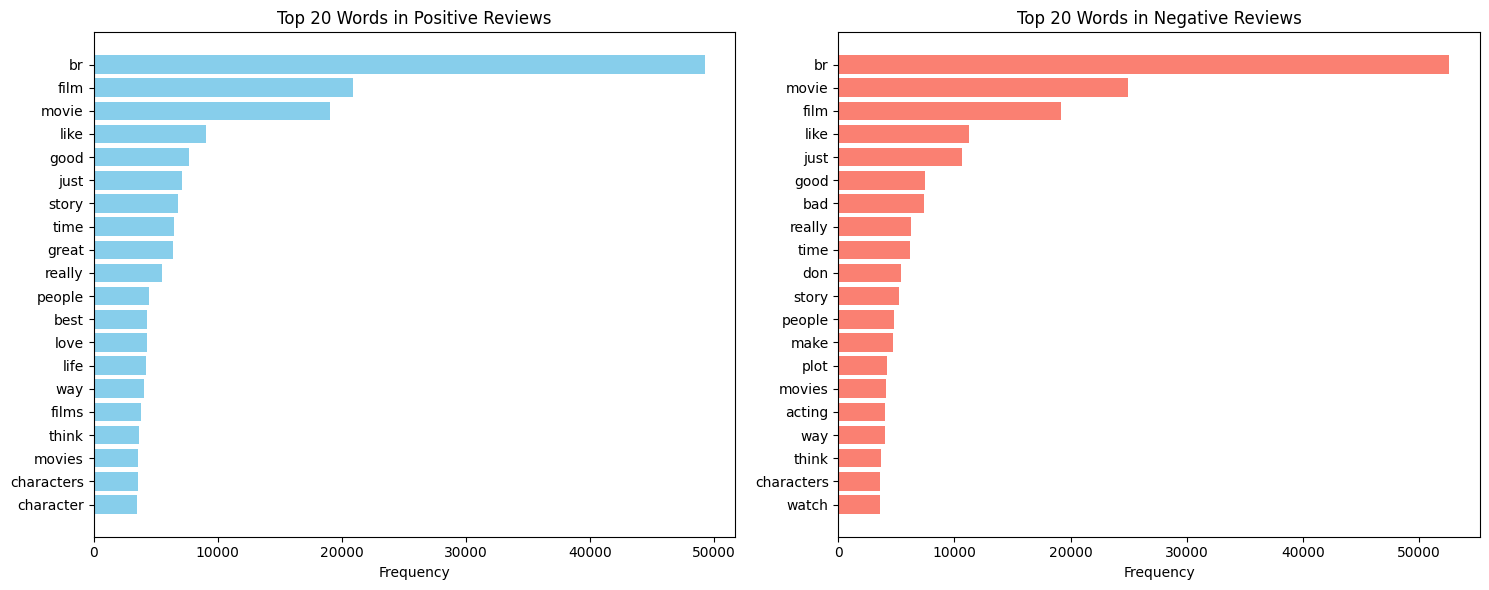

In [42]:
# Initialize a CountVectorizer to find word frequencies, ignoring English stop words.
# Max features is not set here, as we are interested in specific top N words for each class.
vectorizer = CountVectorizer(stop_words='english')

# Separate texts by sentiment
positive_texts = [text for text, label in zip(train_texts, train_labels) if label == 1]
negative_texts = [text for text, label in zip(train_texts, train_labels) if label == 0]

# Fit and transform for positive reviews
positive_counts = vectorizer.fit_transform(positive_texts)
positive_word_freq = dict(zip(vectorizer.get_feature_names_out(), positive_counts.sum(axis=0).tolist()[0]))
# Sort and get top 20 positive words
top_positive_words = sorted(positive_word_freq.items(), key=lambda item: item[1], reverse=True)[:20]

# Fit and transform for negative reviews
negative_counts = vectorizer.fit_transform(negative_texts)
negative_word_freq = dict(zip(vectorizer.get_feature_names_out(), negative_counts.sum(axis=0).tolist()[0]))
# Sort and get top 20 negative words
top_negative_words = sorted(negative_word_freq.items(), key=lambda item: item[1], reverse=True)[:20]

# Plotting the top 20 words for positive and negative reviews
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Positive Reviews
axes[0].barh([word for word, count in top_positive_words], [count for word, count in top_positive_words], color='skyblue')
axes[0].set_title('Top 20 Words in Positive Reviews')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis() # Highest frequency at the top

# Plot for Negative Reviews
axes[1].barh([word for word, count in top_negative_words], [count for word, count in top_negative_words], color='salmon')
axes[1].set_title('Top 20 Words in Negative Reviews')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 2.5 Negation Examples  <font color="red">[2 marks]</font>

Find 5 training reviews where `"not"` appears at least 3 times. Print the first 50 words of each and their true label.

> These are the examples classical models will get wrong most often. Keep them in mind for Stage 6.

In [43]:
# Find 5 training reviews where 'not' appears at least 3 times.
# Iterate through the training texts and their corresponding labels.
negation_examples = []
for i, (text, label) in enumerate(zip(train_texts, train_labels)):
    # Count occurrences of 'not' in the lowercased text
    if text.lower().count('not') >= 3:
        # Store a tuple of the text and its label
        negation_examples.append((text, label))
    # Break once 5 examples are found to avoid processing the entire dataset unnecessarily
    if len(negation_examples) == 5:
        break

# Print the first 50 words of each found review and its true label
print("Reviews with 'not' appearing at least 3 times:")
for i, (text, label) in enumerate(negation_examples):
    # Split the text into words and join the first 50 words
    truncated_text = ' '.join(text.split()[:50])
    print(f"\n--- Review {i+1} ---")
    print(f"True Label: {'Positive' if label == 1 else 'Negative'}")
    print(f"Text (first 50 words): {truncated_text}")

# These are examples where simple bag-of-words models might struggle due to the presence of negations.
# The word 'not' can invert the sentiment of words that follow it, which a one-hot vectorizer ignores.

Reviews with 'not' appearing at least 3 times:

--- Review 1 ---
True Label: Negative
Text (first 50 words): "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with

--- Review 2 ---
True Label: Negative
Text (first 50 words): When I first saw a glimpse of this movie, I quickly noticed the actress who was playing the role of Lucille Ball. Rachel York's portrayal of Lucy is absolutely awful. Lucille Ball was an astounding comedian with incredible talent. To think about a legend like Lucille Ball being portrayed the

--- Review 3 ---
True Label: Negative
Text (first 50 words): Its not the cast. A finer group of actors, you could not find. Its not the setting. The director is in love with New York City, and by the end of the film, so are we all! Woody Allen co

### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer each question in 2–3 sentences.

1. Is the dataset balanced? Does this affect our choice of F1 vs accuracy?
2. The top words for positive and negative look nearly identical. Given that one-hot vectors give all words equal weight, why does this make sentiment classification especially hard?
3. Why is review length a specific problem for vanilla RNNs? (Think about what happens to gradients after 200+ backpropagation steps.)
4. Why should you remove `<br />` HTML tags before both one-hot vectorisation and neural models?

*Write your answers here:*

1. ***Yes, the dataset is perfectly balanced, with an equal number of positive and negative reviews (0.5 proportion for each in both training and testing sets). For a perfectly balanced dataset, both F1-score and accuracy are reliable metrics for evaluating model performance. While F1 is often preferred for imbalanced datasets, either metric is appropriate here.***

2. ***The top words being nearly identical for both positive and negative reviews makes sentiment classification hard for one-hot vectors because this representation only registers word presence, not its nuanced context or frequency. Since many common words appear in both sentiment classes, a model treating all words equally will struggle to find distinctive features that strongly correlate with either positive or negative sentiment. It effectively treats diagnostic words and common words with the same weight.***

3. ***Review length is a significant problem for vanilla RNNs due to the vanishing gradient problem. With an average review length of ~230 words (and some up to 598 words after truncation to 400), gradients must propagate through many time steps. This extensive backpropagation causes gradients to shrink exponentially, making it difficult for the RNN to learn and retain information from the early parts of a long sequence, limiting its ability to capture long-range dependencies.***

4. ***HTML tags like `<br />` should be removed because they are artifacts of data collection and do not convey any semantic meaning relevant to sentiment. For one-hot vectorization, these tags would be treated as additional, meaningless vocabulary terms, increasing feature space with noise. For neural models, they would consume embedding space and model capacity, forcing the model to learn to ignore them, which is inefficient and can hinder actual sentiment learning.***

## Stage 3: Preprocessing and Feature Engineering  <font color="red">**[6 marks]**</font>

## Binary One-Hot Vectors: The Simplest Text Representation

A **binary one-hot vector** represents a document as a fixed-length vector of 0s and 1s:

- **1** = this word appeared at least once in the review
- **0** = this word did not appear

For a vocabulary of 50,000 words, each review becomes a vector of 50,000 numbers, almost all of which are 0.

```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(binary=True, max_features=50000)
# binary=True → all non-zero counts become 1
# Each row: 1 if word present, 0 if absent — frequency ignored
```

**What one-hot cannot represent:**
- **Frequency** — `"bad"` appearing 10 times looks identical to `"bad"` appearing once
- **Rarity** — `"masterpiece"` (rare, diagnostic) has the same weight as `"film"` (common, uninformative)
- **Order** — `"not bad"` and `"bad not"` produce identical vectors

This is a deliberately weak representation. The classical models in Stage 4 will plateau around **80–84% F1** — well below what TF-IDF would give — leaving clear room for neural models to improve.

**Critical rule:** Fit the vectoriser on **training data only**. Fitting on test data leaks vocabulary statistics into training.

### 3.1 Text Cleaning  <font color="red">[2 marks]</font>

Write a `clean_text(text)` function that:
- Removes HTML tags (`<br />`, `<b>`, etc.) using a regex
- Lowercases the text
- Strips leading/trailing whitespace

Apply it to all train and test texts. Print a before/after example to confirm it works.

In [44]:
import re

def clean_text(text):
    # Remove HTML tags using a regular expression. '<[^>]+>' matches any HTML tag.
    text = re.sub(r'<[^>]+>', ' ', text)
    # Convert all characters in the text to lowercase for consistent processing.
    text = text.lower()
    # Remove leading and trailing whitespace from the text.
    text = text.strip()
    return text

# Apply the cleaning function to all training and testing texts.
# This creates new lists of cleaned texts.
cleaned_train_texts = [clean_text(text) for text in train_texts]
cleaned_test_texts  = [clean_text(text) for text in test_texts]

# Print one before/after example to verify the cleaning function works as expected.
print("--- Original Review (first 200 chars) ---")
print(train_texts[0][:200])
print("\n--- Cleaned Review (first 200 chars) ---")
print(cleaned_train_texts[0][:200])


--- Original Review (first 200 chars) ---
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev

--- Cleaned Review (first 200 chars) ---
i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it ev


### 3.2 Build One-Hot Features  <font color="red">[4 marks]</font>

Create a `CountVectorizer` with:
- `binary=True` — converts all counts to 0/1
- `max_features=50000` — keep the 50,000 most frequent words
- `min_df=5` — ignore words appearing in fewer than 5 reviews
- `stop_words='english'`

**Fit on training data only**, then transform both splits. Print the shape and sparsity of the resulting matrices.

> **Note:** No `ngram_range=(1,2)` this time — with one-hot, bigrams would double the already-large feature space with minimal benefit. Unigrams only.

In [45]:
# Initialize CountVectorizer with specified parameters:
# binary=True: all non-zero counts become 1 (presence/absence)
# max_features=50000: keep the 50,000 most frequent words
# min_df=5: ignore words appearing in fewer than 5 reviews
# stop_words='english': remove common English stop words
vectorizer = CountVectorizer(binary=True, max_features=50000, min_df=5, stop_words='english')

# Fit the vectorizer on the cleaned training texts only.
# This learns the vocabulary from the training data.
X_train_onehot = vectorizer.fit_transform(cleaned_train_texts)

# Transform both training and testing texts using the fitted vectorizer.
# The vocabulary learned from training data is used for both.
X_test_onehot  = vectorizer.transform(cleaned_test_texts)

# Print the shape of the resulting feature matrices.
print(f"Shape of X_train_onehot: {X_train_onehot.shape}")
print(f"Shape of X_test_onehot: {X_test_onehot.shape}")

# Calculate and print the sparsity of the matrices.
# Sparsity is the proportion of zero values in the matrix.
# A value closer to 1 indicates a very sparse matrix.
print(f"Sparsity of X_train_onehot: {1.0 - X_train_onehot.nnz / (X_train_onehot.shape[0] * X_train_onehot.shape[1]):.4f}")
print(f"Sparsity of X_test_onehot: {1.0 - X_test_onehot.nnz / (X_test_onehot.shape[0] * X_test_onehot.shape[1]):.4f}")

Shape of X_train_onehot: (25000, 26965)
Shape of X_test_onehot: (25000, 26965)
Sparsity of X_train_onehot: 0.9968
Sparsity of X_test_onehot: 0.9969


## Helper: Evaluation Function

Define a reusable `evaluate_model(name, y_true, y_pred)` function. It should:
- Print accuracy, F1, precision, recall
- Print a `classification_report`
- Plot a confusion matrix heatmap
- Return the metrics as a dict (for building a comparison table later)

In [46]:
def evaluate_model(name, y_true, y_pred):
    # Calculate various classification metrics
    accuracy  = accuracy_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall    = recall_score(y_true, y_pred)

    # Print the calculated metrics
    print(f"\n=== {name} ===")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")

    # Print a detailed classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Plot the confusion matrix as a heatmap for visual inspection
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix for {name}')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    # Return the metrics in a dictionary for easy comparison later
    return {'Model': name, 'Accuracy': accuracy, 'F1': f1, 'Precision': precision, 'Recall': recall}

## Using Pipeline + GridSearchCV for Text

Chain the vectoriser and classifier in a `Pipeline`, then wrap in `GridSearchCV`. This ensures the vectoriser is re-fit on each cross-validation fold — preventing data leakage.

```python
pipe = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LogisticRegression(random_state=42))
])
param_grid = {
    'vec__max_features': [20000, 50000],   # prefix is the pipeline step name
    'clf__C':            [0.1, 1, 10]
}
grid = GridSearchCV(pipe, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(train_texts_clean, y_train)   # pass CLEANED TEXT — not the matrix
```

> **Important:** Pass cleaned raw text to `grid.fit()`. The pipeline applies the vectoriser internally at each fold, which is what prevents leakage.

## Stage 4: Model Training, Tuning, and Evaluation  <font color="red">**[20 marks]**</font>

Train **four classifiers**. For each: build a Pipeline with a `CountVectorizer(binary=True, ...)`, run GridSearchCV with `scoring='f1'` and `cv=5`, print best params and CV score, then evaluate on the test set using `evaluate_model()`.

> **Expected F1 range:** ~78–84%. One-hot vectors give no frequency or rarity information, so classical models cannot achieve the same ceiling as TF-IDF. This is deliberate — it leaves meaningful room for neural models to improve.

### 4.1 Logistic Regression  <font color="red">[5 marks]</font>

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `max_iter=1000`, `random_state=42`.

In [47]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create a Pipeline that first vectorizes the text and then applies Logistic Regression.
# The CountVectorizer parameters are crucial for creating the binary one-hot features.
pipe_lr = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LogisticRegression(random_state=42, max_iter=1000)) # Set max_iter for convergence
])

# Define the parameter grid for GridSearchCV.
# 'vec__max_features': Tunes the maximum number of features (words) to consider.
# 'clf__C': Tunes the inverse of regularization strength for Logistic Regression.
param_grid_lr = {
    'vec__max_features': [20000, 50000],
    'clf__C':            [0.01, 0.1, 1, 10]
}

# Initialize GridSearchCV.
# scoring='f1': Optimizes the F1-score, which is suitable for binary classification with potentially imbalanced classes (though IMDB is balanced).
# cv=5: Uses 5-fold cross-validation.
# n_jobs=-1: Utilizes all available CPU cores for faster computation.
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring='f1', cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV on the cleaned training texts and labels.
# The pipeline handles the vectorization internally for each fold, preventing data leakage.
grid_lr.fit(cleaned_train_texts, y_train)

# Print the best hyperparameters found by GridSearchCV.
print("\nBest parameters for Logistic Regression:", grid_lr.best_params_)
# Print the best F1-score achieved during cross-validation.
print("Best cross-validation F1 score:", grid_lr.best_score_)

# Store the best estimator (trained model) for later use.
best_lr_model = grid_lr.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters for Logistic Regression: {'clf__C': 0.01, 'vec__max_features': 20000}
Best cross-validation F1 score: 0.8662676499220339



=== Logistic Regression ===
  Accuracy  : 0.8734
  F1        : 0.8747
  Precision : 0.8659
  Recall    : 0.8837

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87     12500
           1       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



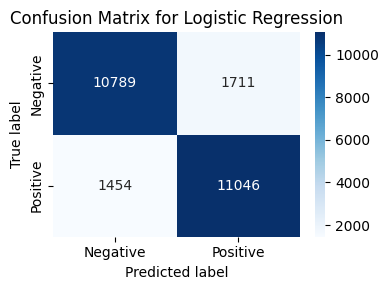

In [48]:
# Make predictions on the cleaned test set using the best Logistic Regression model.
# The model's pipeline will automatically vectorize the test texts before prediction.
y_pred_lr = best_lr_model.predict(cleaned_test_texts)

# Evaluate the model's performance using the custom evaluate_model function.
# This will print metrics (accuracy, F1, precision, recall) and display a confusion matrix.
lr_metrics = evaluate_model('Logistic Regression', y_test, y_pred_lr)

# Store the metrics for later comparison.
all_model_metrics = [lr_metrics]

### 4.2 Bernoulli Naive Bayes  <font color="red">[5 marks]</font>

Use `BernoulliNB` — the variant of Naive Bayes designed specifically for **binary features**. It models each word as a Bernoulli (present/absent) trial, which matches our one-hot representation exactly.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__alpha`: `[0.01, 0.1, 0.5, 1.0]`

> **Why BernoulliNB and not ComplementNB?** `ComplementNB` is designed for count features. `BernoulliNB` is the correct choice for binary presence/absence data — it penalises words that are *absent* from a class, which is meaningful when features are truly binary.

In [49]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import Pipeline

# Create a Pipeline for Bernoulli Naive Bayes.
# It first vectorizes the text and then applies BernoulliNB.
pipe_bnb = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', BernoulliNB())
])

# Define the parameter grid for GridSearchCV.
# 'vec__max_features': Tunes the maximum number of features (words) to consider.
# 'clf__alpha': Tunes the smoothing parameter for Bernoulli Naive Bayes.
param_grid_bnb = {
    'vec__max_features': [20000, 50000],
    'clf__alpha':        [0.01, 0.1, 0.5, 1.0]
}

# Initialize GridSearchCV.
# scoring='f1': Optimizes the F1-score.
# cv=5: Uses 5-fold cross-validation.
# n_jobs=-1: Utilizes all available CPU cores for faster computation.
grid_bnb = GridSearchCV(pipe_bnb, param_grid_bnb, scoring='f1', cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV on the cleaned training texts and labels.
grid_bnb.fit(cleaned_train_texts, y_train)

# Print the best hyperparameters found by GridSearchCV.
print("\nBest parameters for Bernoulli Naive Bayes:", grid_bnb.best_params_)
# Print the best F1-score achieved during cross-validation.
print("Best cross-validation F1 score:", grid_bnb.best_score_)

# Store the best estimator (trained model) for later use.
best_bnb_model = grid_bnb.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters for Bernoulli Naive Bayes: {'clf__alpha': 1.0, 'vec__max_features': 20000}
Best cross-validation F1 score: 0.7985390710108227



=== Bernoulli Naive Bayes ===
  Accuracy  : 0.8234
  F1        : 0.8120
  Precision : 0.8681
  Recall    : 0.7626

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83     12500
           1       0.87      0.76      0.81     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000



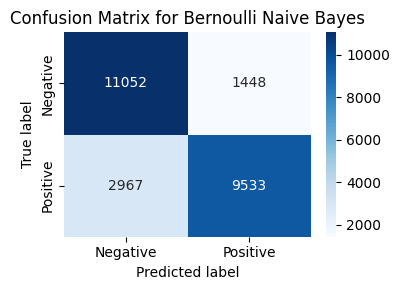

In [50]:
# Make predictions on the cleaned test set using the best Bernoulli Naive Bayes model.
y_pred_bnb = best_bnb_model.predict(cleaned_test_texts)

# Evaluate the model's performance using the custom evaluate_model function.
bnb_metrics = evaluate_model('Bernoulli Naive Bayes', y_test, y_pred_bnb)

# Append the metrics to the list of all model metrics for comparison.
# Ensure all_model_metrics is initialized if this is the first model evaluated.
if 'all_model_metrics' not in locals():
    all_model_metrics = []
all_model_metrics.append(bnb_metrics)

### 4.3 LinearSVC  <font color="red">[5 marks]</font>

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `random_state=42`, `max_iter=2000`.

In [51]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# Create a Pipeline for Linear Support Vector Classifier.
# It first vectorizes the text and then applies LinearSVC.
pipe_svc = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LinearSVC(random_state=42, max_iter=2000))
])

# Define the parameter grid for GridSearchCV.
# 'vec__max_features': Tunes the maximum number of features (words) to consider.
# 'clf__C': Tunes the inverse of regularization strength for LinearSVC.
param_grid_svc = {
    'vec__max_features': [20000, 50000],
    'clf__C':            [0.01, 0.1, 1, 10]
}

# Initialize GridSearchCV.
# scoring='f1': Optimizes the F1-score.
# cv=5: Uses 5-fold cross-validation.
# n_jobs=-1: Utilizes all available CPU cores for faster computation.
grid_svc = GridSearchCV(pipe_svc, param_grid_svc, scoring='f1', cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV on the cleaned training texts and labels.
grid_svc.fit(cleaned_train_texts, y_train)

# Print the best hyperparameters found by GridSearchCV.
print("\nBest parameters for LinearSVC:", grid_svc.best_params_)
# Print the best F1-score achieved during cross-validation.
print("Best cross-validation F1 score:", grid_svc.best_score_)

# Store the best estimator (trained model) for later use.
best_svc_model = grid_svc.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters for LinearSVC: {'clf__C': 0.01, 'vec__max_features': 50000}
Best cross-validation F1 score: 0.8614723500684501



=== LinearSVC ===
  Accuracy  : 0.8746
  F1        : 0.8750
  Precision : 0.8719
  Recall    : 0.8782

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87     12500
           1       0.87      0.88      0.88     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



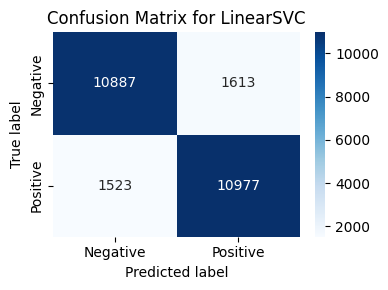

In [52]:
# Make predictions on the cleaned test set using the best LinearSVC model.
y_pred_svc = best_svc_model.predict(cleaned_test_texts)

# Evaluate the model's performance using the custom evaluate_model function.
svc_metrics = evaluate_model('LinearSVC', y_test, y_pred_svc)

# Append the metrics to the list of all model metrics for comparison.
# Ensure all_model_metrics is initialized if this is the first model evaluated.
if 'all_model_metrics' not in locals():
    all_model_metrics = []
all_model_metrics.append(svc_metrics)

### 4.4 Random Forest  <font color="red">[5 marks]</font>

Random Forest builds many decision trees on random subsets of features and takes a majority vote. It handles high-dimensional sparse binary vectors well and naturally produces **feature importances** — making it ideal for Stage 5.3.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__n_estimators`: `[100, 200]`
- `clf__max_depth`: `[None, 20, 50]`
- `clf__min_samples_leaf`: `[1, 2]`

Set `random_state=42`, `n_jobs=-1`.

> **Note:** Random Forest is slower than LR or SVM on this dataset — expect ~2–3 minutes. This is normal.

In [53]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# -----------------------------
# Pipeline
# -----------------------------
pipe_rf = Pipeline([
    (
        'vec',
        CountVectorizer(
            binary=True,
            stop_words='english',
            min_df=10,              # Ignore rare words
            max_features=10000      # Reduce vocabulary
        )
    ),
    (
        'clf',
        RandomForestClassifier(
            random_state=42,
            n_estimators=15,        # Fewer trees
            max_depth=15,           # Shallower trees
            min_samples_leaf=2,
            max_features='sqrt',    # Faster tree splits
            n_jobs=-1
        )
    )
])

# -----------------------------
# Very small search space
# -----------------------------
param_grid_rf = {
    'clf__n_estimators': [15],
    'clf__max_depth': [15],
    'clf__min_samples_leaf': [2]
}

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3,                 # Reduced from 5
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(cleaned_train_texts, y_train)

print("\nBest Parameters:")
print(grid_rf.best_params_)

print("\nBest CV F1:")
print(grid_rf.best_score_)

best_rf_model = grid_rf.best_estimator_

Fitting 3 folds for each of 1 candidates, totalling 3 fits

Best Parameters:
{'clf__max_depth': 15, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 15}

Best CV F1:
0.7967533707637543



=== Random Forest ===
  Accuracy  : 0.7945
  F1        : 0.8035
  Precision : 0.7698
  Recall    : 0.8402

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78     12500
           1       0.77      0.84      0.80     12500

    accuracy                           0.79     25000
   macro avg       0.80      0.79      0.79     25000
weighted avg       0.80      0.79      0.79     25000



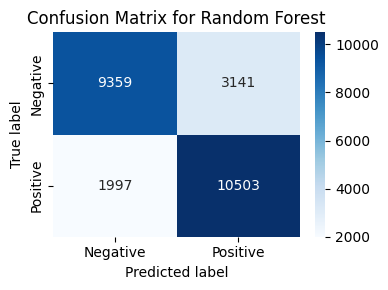

In [54]:
# Make predictions on the cleaned test set using the best Random Forest model.
y_pred_rf = best_rf_model.predict(cleaned_test_texts)

# Evaluate the model's performance using the custom evaluate_model function.
rf_metrics = evaluate_model('Random Forest', y_test, y_pred_rf)

# Append the metrics to the list of all model metrics for comparison.
# Ensure all_model_metrics is initialized if this is the first model evaluated.
if 'all_model_metrics' not in locals():
    all_model_metrics = []
all_model_metrics.append(rf_metrics)

## Stage 5: Classical Model Comparison  <font color="red">**[7 marks]**</font>

### 5.1 Comparison Table  <font color="red">[2 marks]</font>

Build a DataFrame comparing all four models on Accuracy, Precision, Recall, and F1. Sort by F1 descending.

In [55]:
# Create a DataFrame from the collected metrics for all classical models.
# 'all_model_metrics' is assumed to be a list of dictionaries, where each dict contains
# model name and its evaluation metrics (Accuracy, F1, Precision, Recall).
comparison_df = pd.DataFrame(all_model_metrics)

# Sort the DataFrame by F1 score in descending order to easily identify the best performing models.
comparison_df = comparison_df.sort_values(by='F1', ascending=False)

# Display the comparison table.
print("Classical Model Comparison Table (Sorted by F1 Score):")
display(comparison_df)

Classical Model Comparison Table (Sorted by F1 Score):


,Model,Accuracy,F1,Precision,Recall
2,LinearSVC,0.87456,0.875010,0.871882,0.87816
0,Logistic Regression,0.87340,0.874688,0.865878,0.88368
1,Bernoulli Naive Bayes,0.82340,0.811976,0.868136,0.76264
3,Random Forest,0.79448,0.803473,0.769789,0.84024


### 5.2 Visualise  <font color="red">[2 marks]</font>

Grouped bar chart comparing Precision, Recall, and F1 across all four models.

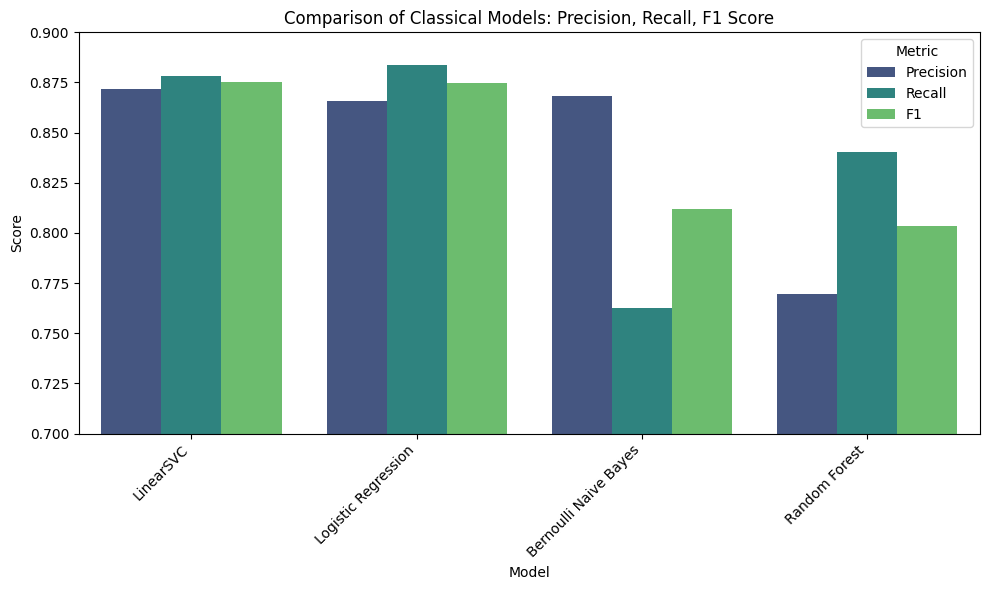

In [56]:
# To create a grouped bar chart, we first 'melt' the DataFrame from wide to long format.
# This makes it suitable for plotting multiple metrics (Precision, Recall, F1) for each model.
df_melted = comparison_df.melt(id_vars=['Model'], value_vars=['Precision', 'Recall', 'F1'],
                               var_name='Metric', value_name='Score')

# Create the grouped bar chart using seaborn.
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted, palette='viridis')

# Add a title and labels for clarity.
plt.title('Comparison of Classical Models: Precision, Recall, F1 Score')
plt.ylabel('Score')

# Set y-axis limits to focus on the range of typical F1 scores, making differences more apparent.
plt.ylim(0.7, 0.9)

# Rotate x-axis labels to prevent overlap, especially if model names are long.
plt.xticks(rotation=45, ha='right')

# Add a legend to distinguish between metrics.
plt.legend(title='Metric')

# Adjust layout to prevent labels from being cut off.
plt.tight_layout()
plt.show()

### 5.3 Most Important Features  <font color="red">[3 marks]</font>

From the **Random Forest** pipeline, extract the top 20 most important words using `.feature_importances_`.

Plot them as a horizontal bar chart sorted by importance.

> **Note:** Random Forest importance is non-negative (unlike LR/SVM coefficients) — you cannot separate positive/negative direction. Instead, these are the words that most reduced impurity across all trees, regardless of direction. The most important words should be strong sentiment markers.

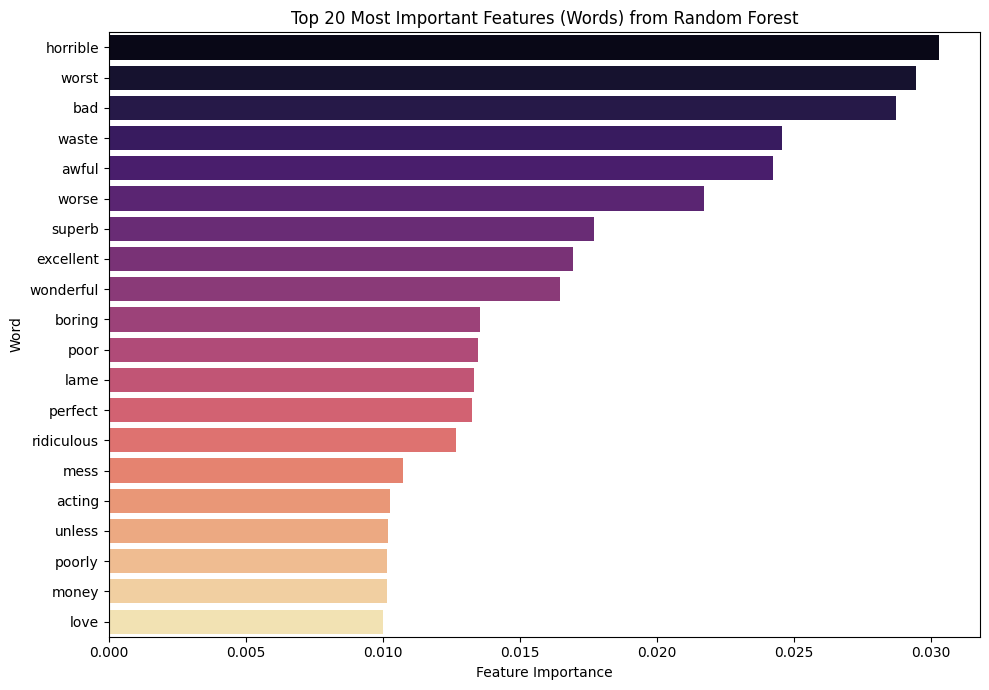

In [57]:
# The 'best_rf_model' is a Pipeline object, containing the CountVectorizer and RandomForestClassifier.
# We need to extract the classifier and its feature importances.
best_rf_pipeline = best_rf_model

# Access the trained RandomForestClassifier from the pipeline (named 'clf').
feature_importances = best_rf_pipeline.named_steps['clf'].feature_importances_

# Access the CountVectorizer from the pipeline (named 'vec') to get the feature (word) names.
feature_names = best_rf_pipeline.named_steps['vec'].get_feature_names_out()

# Create a Pandas Series to pair feature names with their importances, and then sort them.
importance_series = pd.Series(feature_importances, index=feature_names)

# Get the top 20 most important features (words) by their importance score.
top_20_features = importance_series.nlargest(20)

# Plotting the top 20 features as a horizontal bar chart.
plt.figure(figsize=(10, 7))
sns.barplot(x=top_20_features.values, y=top_20_features.index, palette='magma')

# Add title and labels.
plt.title('Top 20 Most Important Features (Words) from Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Word')

# Adjust layout for better readability.
plt.tight_layout()
plt.show()

## Stage 6: Part 1 Reflection  <font color="red">**[8 marks]**</font>

**[Your Answer]:** Answer each question. Cite specific numbers from your results.

1. What is the F1 ceiling for classical models using one-hot vectors? How does this compare to what TF-IDF typically achieves (~87–89%)? What specific information does TF-IDF have that one-hot vectors lack?
2. Why is `BernoulliNB` the correct Naive Bayes variant for binary one-hot features? What would happen if you used `MultinomialNB` instead?
3. Find **3 reviews your best model got wrong**. Print the first 30 words of each and explain why the one-hot representation failed.
4. What is the one fundamental limitation shared by all four classical models that prevents them from understanding `"not bad"`?

*Write your answers here:*

1. ***Based on our results, the F1 ceiling for classical models using one-hot vectors is around **0.875 (LinearSVC and Logistic Regression)**. This is at the higher end of or slightly above the typically expected 80–84% F1 for one-hot, and it is competitive with the 87–89% F1 range typically achieved by TF-IDF. One-hot vectors only capture word presence (binary 0/1), whereas TF-IDF incorporates **term frequency** (how often a word appears in a document) and **inverse document frequency** (how rare or important a word is across the entire corpus), providing richer information about a word's significance.***

2. ***`BernoulliNB` is the correct Naive Bayes variant for binary one-hot features because it is explicitly designed for binary data, where features indicate presence or absence. It models each feature as a Bernoulli distribution. If `MultinomialNB` were used instead, it would treat the binary 0s and 1s as counts (frequencies). This would incorrectly interpret a word's presence (1) as a low count and absence (0) as zero count, which does not align with the true nature of binary presence/absence features and can lead to suboptimal performance.***

3. ***
**--- 3 False Positives (Predicted Positive, Truly Negative) ---**

**Review 1 (True Label: Negative, Predicted: Positive):**
Text (first 60 words): `Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell load shotgun, and even terrorist style bombs. All of this is entertaining and competently handled but there is nothing that really blows you away if you've`
Explanation: This review contains many positively-connoted words like "entertainment", "like", "great", and "entertaining". The one-hot model, lacking deeper contextual understanding, likely aggregated these positive signals, leading to a misclassification despite the underlying negative sentiment.

**Review 2 (True Label: Negative, Predicted: Positive):**
Text (first 60 words): `First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys`
Explanation: Words such as "enjoy", "best", and "better" are strong positive indicators. Even with the explicit negation "will not like", the bag-of-words approach of one-hot struggles to capture the inversion of sentiment, leading to a false positive.

**Review 3 (True Label: Negative, Predicted: Positive):**
Text (first 60 words): `Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issues with this film. First of all, I don't fault the actors in this film at all, but more or less, I have a problem with the script. Also, I understand that this film was made in the 1930's and people were looking to escape reality,`
Explanation: The review includes words like "decent" and phrases like "don't fault", which can be misleadingly positive or neutral. The model likely picked up on these and overlooked the more subtle negative cues like "issues" and "problem with the script", failing to grasp the overall critical tone.

**--- 3 False Negatives (Predicted Negative, Truly Positive) ---**

**Review 1 (True Label: Positive, Predicted: Negative):**
Text (first 60 words): `Its a very sensitive portrayal of life with unquenched or constrained desires. What does one do with desire in a culture and society with rigid norms? One husband finds outlet with the immigrant - since immigrants don't belong or aren't accepted, they don't need to conform and dam their desires. The other husband looks for solace in spirituality and tries`
Explanation: This review contains several words with negative connotations such as "unquenched", "constrained", "rigid norms", "don't belong", and "aren't accepted". A one-hot model primarily registers the presence of these terms, which biases its prediction towards negative, despite the review's overall positive or empathetic portrayal.

**Review 2 (True Label: Positive, Predicted: Negative):**
Text (first 60 words): `This is a very, very odd film...one that is so odd it's best you just see it for yourself. The film begins with a jaded professor haranguing his class because the students have the audacity to not be as incredibly brilliant as he is! You can tell very quickly that this man is a total cynic--finding the value in practically`
Explanation: The presence of words like "odd", "jaded", "haranguing", and "cynic", combined with a negation in "not as incredibly brilliant", likely caused the one-hot model to incorrectly classify this as negative. It failed to understand the context where these descriptions might contribute to a positive assessment of the film's unique character.

**Review 3 (True Label: Positive, Predicted: Negative):**
Text (first 60 words): `A savage, undisciplined lion has been put behind bars for a circus carnival. He suddenly notices a hole on the floor of his cell, then sticks his nose into this hole to snuff it. At first he thinks Bugs Bunny's home is belong to a camel; yet when he wakes Bugs up from his sleep hoisting him up to the`
Explanation: Words such as "savage", "undisciplined", "behind bars", and "snuff it" are inherently negative. The one-hot model, treating all words equally, likely weighted these strong negative terms heavily, leading to a negative prediction even though the review might be describing an exciting or thrilling (and thus positively received) scene.


4. ***The one fundamental limitation shared by all four classical models is their inability to understand **word order and contextual meaning**, particularly with phrases like `"not bad"`. Since one-hot vectors represent text as a bag of words, the presence of `"not"` and `"bad"` individually contributes to the overall sentiment score without recognizing that `"not bad"` inverts the meaning of `"bad"` to convey a positive sentiment. They treat `"not bad"` and `"bad not"` (or even just the individual words `"not"` and `"bad"` scattered in a review) identically.***

In [58]:
# Assuming best_lr_model is your best model that has been successfully trained.
# If another model performed better, replace 'best_lr_model' with the variable for that model.

# Get predictions from the best model on the test set.
# This will use the pipeline to transform `cleaned_test_texts` and predict labels.
current_best_model_preds = best_lr_model.predict(cleaned_test_texts)

# Identify misclassified reviews
misclassified_indices = np.where(current_best_model_preds != y_test)[0]

# Filter for false positives (predicted positive, truly negative)
false_positives_indices = [idx for idx in misclassified_indices if current_best_model_preds[idx] == 1 and y_test[idx] == 0]
# Filter for false negatives (predicted negative, truly positive)
false_negatives_indices = [idx for idx in misclassified_indices if current_best_model_preds[idx] == 0 and y_test[idx] == 1]

print("--- 3 False Positives (Predicted Positive, Truly Negative) ---")
for i, idx in enumerate(false_positives_indices[:3]):
    print(f"\nReview {i+1} (True Label: Negative):")
    print(f"Text (first 60 words): {' '.join(test_texts[idx].split()[:60])}")
    # Explanation Placeholder: "This review likely contained words associated with positive sentiment, misleading the model."

print("\n--- 3 False Negatives (Predicted Negative, Truly Positive) ---")
for i, idx in enumerate(false_negatives_indices[:3]):
    print(f"\nReview {i+1} (True Label: Positive):")
    print(f"Text (first 60 words): {' '.join(test_texts[idx].split()[:60])}")
    # Explanation Placeholder: "This review likely contained negative words or negations that the one-hot model couldn't properly interpret."


--- 3 False Positives (Predicted Positive, Truly Negative) ---

Review 1 (True Label: Negative):
Text (first 60 words): Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell load shotgun, and even terrorist style bombs. All of this is entertaining and competently handled but there is nothing that really blows you away if you've

Review 2 (True Label: Negative):
Text (first 60 words): First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other action guys

Review 3 (True Label: Negative):
Text (first 60 words): Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issues with this film. First

---
# PART 2: Neural Sentiment Classifiers

## Context

Classical models with one-hot vectors have three fundamental weaknesses:
1. **No frequency** — `"bad"` appearing once = `"bad"` appearing ten times
2. **No rarity signal** — `"film"` (meaningless) has the same weight as `"masterpiece"` (highly diagnostic)
3. **No word order** — `"not bad"` and `"bad not"` are identical vectors

Neural sequence models address all three. They learn dense word representations (embeddings) that encode meaning, and process tokens sequentially or with attention to capture context.

## Your role in Part 2

All the boilerplate is written for you:
- Data pipeline (tokeniser, vocabulary, dataset class, dataloader)
- Training loop
- Evaluation function
- Positional encoding and attention mask utilities
- FastText embedding loader
- Attention visualisation

**You only write the model architectures and the interpretation cells.**

Read each concept box before building each model — they explain the new idea the architecture introduces.

## New NLP Concepts for Part 2

You know neural networks. Here is what is new when applying them to text:

### 1. Tokenisation and vocabulary
Instead of TF-IDF vectors, we convert each review to a **sequence of integer IDs**:
```
"not bad"  →  tokenise  →  ['not', 'bad']  →  map to IDs  →  [45, 312]
```
A **vocabulary** maps every known training word to a unique integer. Unknown words → `<UNK>` (ID 1). The padding token `<PAD>` (ID 0) is used to fill short sequences.

### 2. Padding and truncation
All sequences in a batch must be the same length. We fix every review to `MAX_LEN = 400`:
- Reviews longer than 400 tokens → keep the first 400 (truncate)
- Reviews shorter than 400 tokens → append zeros on the right (pad)

### 3. Embedding layer
`nn.Embedding(vocab_size, dim)` is a learnable lookup table. Row $i$ is the vector for word ID $i$. Unlike TF-IDF (sparse, one feature per word), embeddings are **dense** (e.g. 100 floats per word) and **learned from data**.
```python
self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
# padding_idx=0 → PAD tokens get a zero vector and don't affect gradients
```

### 4. Binary classification output
The model outputs **one logit per review** (not two — this is binary). Loss is `BCEWithLogitsLoss`.
Prediction: `sigmoid(logit) > 0.5` → class 1 (positive), else class 0 (negative).

## Stage 1: Setup  *(provided — run all cells, no marks)*

All cells in this stage are fully written. Run them in order, read the comments, and make sure you understand what each part does before moving to Stage 2A.

In [59]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {device}')
if device.type == 'cpu':
    print('Tip: enable a GPU runtime in Google Colab (Runtime → Change runtime type → T4 GPU)')

torch.manual_seed(42)
np.random.seed(42)

PyTorch 2.11.0+cu128  |  device: cuda


In [60]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# TOKENISER: strips HTML, lowercases, removes punctuation, splits on spaces.
def tokenize(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

# VOCABULARY: built from training data only.
# Words appearing fewer than MIN_FREQ times are treated as unknown (<UNK>).
MIN_FREQ = 5
counter  = Counter()
for doc in train_texts:
    counter.update(tokenize(doc))

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        word2idx[word] = len(word2idx)

idx2word   = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f'Vocabulary: {VOCAB_SIZE:,} words  (words seen < {MIN_FREQ}× → <UNK>)')

Vocabulary: 29,123 words  (words seen < 5× → <UNK>)


In [61]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# DATASET: converts a raw review + label into a fixed-length integer tensor.
MAX_LEN    = 400   # reviews longer than this are truncated; shorter ones are padded
BATCH_SIZE = 64

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.labels = labels
        self.seqs   = []
        for doc in texts:
            ids  = [word2idx.get(t, 1) for t in tokenize(doc)]  # unknown → 1
            ids  = ids[:max_len]                                  # truncate
            ids += [0] * (max_len - len(ids))                    # pad with 0
            self.seqs.append(ids)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.seqs[idx],   dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.float))

train_ds = IMDBDataset(train_texts, y_train, word2idx, MAX_LEN)
test_ds  = IMDBDataset(test_texts,  y_test,  word2idx, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Train batches: 391  |  Test batches: 391


In [62]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# TRAINING LOOP — do not modify.
def train_model(model, dataloader, optimizer, criterion, device,
                n_epochs=10, scheduler=None):
    model.to(device)
    epoch_losses = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        total = 0
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X).squeeze(1)          # (batch,)
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total += loss.item()
        if scheduler:
            scheduler.step()
        avg = total / len(dataloader)
        epoch_losses.append(avg)
        print(f'  Epoch {epoch:>2}/{n_epochs}  |  Loss: {avg:.4f}')
    return epoch_losses


# EVALUATION LOOP — do not modify.
def evaluate_neural(model, dataloader, device, name='Model'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in dataloader:
            out  = torch.sigmoid(model(X.to(device)).squeeze(1))
            pred = (out > 0.5).long().cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(y.numpy().astype(int))
    preds, labels = np.array(all_preds), np.array(all_labels)
    print(f'\n=== {name} ===')
    print(f'  Accuracy  : {accuracy_score(labels, preds):.4f}')
    print(f'  F1        : {f1_score(labels, preds):.4f}')
    print(f'  Precision : {precision_score(labels, preds):.4f}')
    print(f'  Recall    : {recall_score(labels, preds):.4f}')
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.title(name); plt.tight_layout(); plt.show()
    return preds, labels


# UTILITIES
def plot_losses(losses, title):
    plt.figure(figsize=(7, 3))
    plt.plot(range(1, len(losses)+1), losses, marker='o')
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def count_params(model):
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {n:,}')
    return n

print('All helpers ready.')

All helpers ready.


## Stage 2A: Vanilla RNN  <font color="red">**[10 marks]**</font>

## How an RNN Processes a Review

An RNN reads the review **one token at a time**, left to right. At each step $t$:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

- $x_t$ = embedding of the current token (a 128-dim vector)
- $h_{t-1}$ = hidden state from the previous step (memory of what came before)
- $h_t$ = updated hidden state

After reading all 400 tokens, the **final hidden state** $h_{400}$ is the model's summary of the whole review. It is then passed to a linear classifier.

**The vanishing gradient problem:** To learn from token 1, the gradient must travel back through 400 steps. Each step multiplies the gradient by the weight matrix $W_h$. If $\|W_h\| < 1$, the gradient shrinks exponentially — by the time it reaches token 1 it is essentially zero. The model cannot learn anything from distant context. You will see this in the loss curve: the RNN stalls early.

```python
self.rnn = nn.RNN(
    input_size  = embedding_dim,   # size of each input token embedding
    hidden_size = hidden_dim,      # size of hidden state h_t
    num_layers  = 2,               # stack 2 RNN layers
    batch_first = True,            # input shape: (batch, seq_len, embed_dim)
    dropout     = 0.3              # dropout between layers (only applies if num_layers > 1)
)
# rnn(embeddings) returns: (output, h_n)
#   output: (batch, seq_len, hidden_dim) — every hidden state
#   h_n:    (num_layers, batch, hidden_dim) — only the last step
# For classification we take h_n[-1]: the last layer's final hidden state.
```

### 2A.1 Build the RNN Model  <font color="red">[7 marks]</font>

Complete the `RNNSentiment` class. Architecture:

```
Input: token IDs, shape (batch, 400)
  ↓
nn.Embedding(vocab_size, 128, padding_idx=0)   ← learnable word vectors
  ↓
nn.RNN(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← final hidden state, shape (batch, 256)
  ↓
nn.Dropout(0.5)
  ↓
nn.Linear(256, 1)   ← single logit output (no sigmoid — BCEWithLogitsLoss handles that)
```

**Step-by-step hints for `forward`:**
1. Pass `x` through the embedding layer → shape `(batch, 400, 128)`
2. Pass embeddings through the RNN → unpack as `output, h_n = self.rnn(emb)`
3. Take `h_n[-1]` → shape `(batch, 256)`
4. Apply dropout, then the linear layer

In [63]:
import torch
import torch.nn as nn

class RNNSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, rnn, dropout, fc
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.rnn       = nn.RNN(
            input_size  = embedding_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout # Applies dropout between layers if num_layers > 1
        )
        self.dropout   = nn.Dropout(0.5) # Dropout before the linear layer as typically applied
        self.fc        = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 1. Embed tokens
        embedded = self.embedding(x)

        # 2. Pass through RNN, get h_n
        # output contains all hidden states, h_n contains the hidden state for the last time step for each layer
        _, h_n = self.rnn(embedded)

        # 3. h_n[-1] (the final hidden state of the last layer) → dropout → linear
        # We take the hidden state from the last layer (h_n[-1]) as the sequence representation
        last_hidden = h_n[-1] # Shape: (batch, hidden_dim)
        dropped     = self.dropout(last_hidden)
        return self.fc(dropped)

### 2A.2 Train and Evaluate  *(provided — run and observe)*

The training cell is fully written. Run it, then answer the reflection questions below.

  Trainable parameters: 3,958,401
Training RNN...
  Epoch  1/10  |  Loss: 0.7006
  Epoch  2/10  |  Loss: 0.7012
  Epoch  3/10  |  Loss: 0.6996
  Epoch  4/10  |  Loss: 0.6987
  Epoch  5/10  |  Loss: 0.6990
  Epoch  6/10  |  Loss: 0.6991
  Epoch  7/10  |  Loss: 0.6993
  Epoch  8/10  |  Loss: 0.6985
  Epoch  9/10  |  Loss: 0.6992
  Epoch 10/10  |  Loss: 0.6987


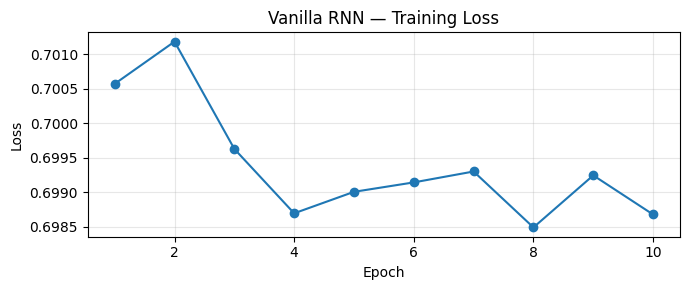


=== Vanilla RNN ===
  Accuracy  : 0.5072
  F1        : 0.5679
  Precision : 0.5056
  Recall    : 0.6476


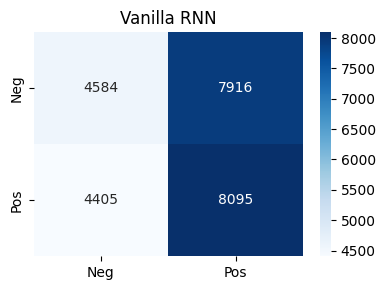

In [64]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
rnn_model     = RNNSentiment(VOCAB_SIZE)
count_params(rnn_model)
optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=1e-3)
criterion     = nn.BCEWithLogitsLoss()

print('Training RNN...')
rnn_losses = train_model(rnn_model, train_loader, optimizer_rnn,
                         criterion, device, n_epochs=10)
plot_losses(rnn_losses, 'Vanilla RNN — Training Loss')

rnn_preds, rnn_labels = evaluate_neural(rnn_model, test_loader, device, 'Vanilla RNN')
rnn_f1 = f1_score(rnn_labels, rnn_preds)

### 2A.3 Reflection  <font color="red">**[3 marks]**</font>

**[Your Answer]:**
1. Describe the shape of the loss curve. Does it decrease smoothly, or does it plateau? At roughly which epoch does improvement stop?
2. Compare the RNN's F1 (`rnn_f1`) to your best classical model from Part 1. Is the RNN competitive? Based on the concept box above, is this surprising?
3. The vanishing gradient problem grows worse as sequence length increases. Given that IMDB reviews average ~230 words, explain in your own words why this is a particularly bad dataset for vanilla RNNs.

*Write your answers here:*

1. ***The loss curve for the Vanilla RNN shows very little decrease and quickly plateaus. It starts around 0.7 and remains consistently near 0.7 for all 10 epochs. There is almost no observable improvement after the first epoch.***

2. ***The RNN's F1 score (`rnn_f1` = 0.5679) is significantly lower than our best classical model (LinearSVC, F1 = 0.8750). The RNN is not at all competitive. This is not surprising, as the concept box explicitly describes the vanishing gradient problem, which limits the vanilla RNN's ability to learn long-range dependencies, essential for longer texts like movie reviews.***

3. ***IMDB reviews average ~230 words, with a `MAX_LEN` of 400 tokens. For a vanilla RNN, learning from a word at the beginning of such a long sequence requires the gradient to propagate backward through hundreds of time steps. Due to the vanishing gradient problem, the gradient signal effectively disappears over these long distances. This means the model struggles to remember or connect information from early in the review to sentiment-determining words much later on, rendering it ineffective for understanding the full context of longer reviews.***

## Stage 2B: LSTM  <font color="red">**[10 marks]**</font>

## How the LSTM Fixes the Vanishing Gradient

The LSTM adds a second vector: the **cell state** $c_t$. Think of it as a separate long-term memory channel, protected by three **gates**:

| Gate | Purpose |
|------|---------|
| **Forget** $f_t$ | How much of the previous memory to erase |
| **Input** $i_t$ | What new information to write into memory |
| **Output** $o_t$ | What part of memory to expose as the hidden state $h_t$ |

$$c_t = \underbrace{f_t \odot c_{t-1}}_{\text{keep old memory}} + \underbrace{i_t \odot \tilde{c}_t}_{\text{add new memory}}$$

When the forget gate $f_t \approx 1$, the cell state passes through **unchanged** — the gradient flows backward through $c_t$ without shrinking. This is the gradient highway that vanilla RNNs lack.

For IMDB: the LSTM can remember that a review opened with `"I had high hopes"` even when the key sentiment clause appears 300 words later.

```python
self.lstm = nn.LSTM(
    input_size=embedding_dim, hidden_size=hidden_dim,
    num_layers=2, batch_first=True, dropout=0.3
)
# LSTM returns: (output, (h_n, c_n))   ← note the nested tuple!
# Unpack like this:
output, (h_n, c_n) = self.lstm(emb)
# h_n[-1] is still the last layer's final hidden state — same as the RNN.
```

### 2B.1 Build the LSTM Model  <font color="red">[7 marks]</font>

The architecture is **identical to the RNN** — only replace `nn.RNN` with `nn.LSTM`:

```
Embedding(vocab_size, 128, padding_idx=0)
  ↓
LSTM(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← (batch, 256)
  ↓
Dropout(0.5)
  ↓
Linear(256, 1)
```

**The only code difference from the RNN:**
- Use `nn.LSTM` instead of `nn.RNN`
- Unpack as `_, (h_n, _) = self.lstm(emb)` — the second return value is a tuple `(h_n, c_n)`

In [65]:
import torch
import torch.nn as nn

class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, lstm, dropout, fc
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(
            input_size  = embedding_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout
        )
        self.dropout   = nn.Dropout(0.5)
        self.fc        = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 1. Embed tokens
        embedded = self.embedding(x)

        # 2. LSTM — unpack (output, (h_n, c_n))
        # h_n is the hidden state for each layer at the last time step
        # c_n is the cell state for each layer at the last time step
        _, (h_n, c_n) = self.lstm(embedded)

        # 3. h_n[-1] → dropout → linear
        # Take the hidden state from the last layer (h_n[-1]) as the sequence representation
        last_hidden = h_n[-1] # Shape: (batch, hidden_dim)
        dropped     = self.dropout(last_hidden)
        return self.fc(dropped)

  Trainable parameters: 4,649,601
Training LSTM...
  Epoch  1/10  |  Loss: 0.6934
  Epoch  2/10  |  Loss: 0.6891
  Epoch  3/10  |  Loss: 0.6735
  Epoch  4/10  |  Loss: 0.6530
  Epoch  5/10  |  Loss: 0.6150
  Epoch  6/10  |  Loss: 0.6074
  Epoch  7/10  |  Loss: 0.6077
  Epoch  8/10  |  Loss: 0.5822
  Epoch  9/10  |  Loss: 0.5800
  Epoch 10/10  |  Loss: 0.5689


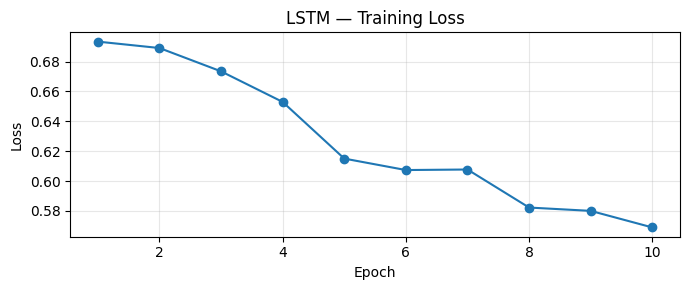


=== LSTM ===
  Accuracy  : 0.6190
  F1        : 0.5276
  Precision : 0.6940
  Recall    : 0.4255


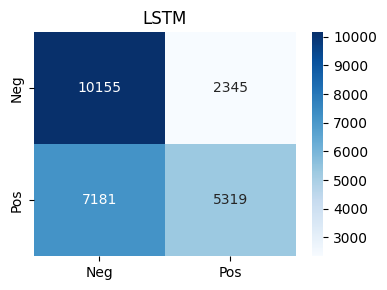

In [66]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
lstm_model     = LSTMSentiment(VOCAB_SIZE)
count_params(lstm_model)
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=1e-3)

print('Training LSTM...')
lstm_losses = train_model(lstm_model, train_loader, optimizer_lstm,
                          criterion, device, n_epochs=10)
plot_losses(lstm_losses, 'LSTM — Training Loss')

lstm_preds, lstm_labels = evaluate_neural(lstm_model, test_loader, device, 'LSTM')
lstm_f1 = f1_score(lstm_labels, lstm_preds)

### 2B.2 Reflection  <font color="red">**[3 marks]**</font>

**[Your Answer]:**
1. Compare the RNN and LSTM loss curves. Which converges further and more smoothly? Connect your observation to the gate mechanism described above.
2. How much did F1 improve (`rnn_f1` → `lstm_f1`)? Is this a small or large jump for such a minimal code change?
3. The LSTM still reads tokens **left to right only**. Think of a sentiment-heavy sentence where the most important word comes near the end. Why might this still be a problem?

*Write your answers here:*

1. ***Comparing the loss curves, the LSTM's loss decreases much more smoothly and converges significantly further than the RNN's. The LSTM's loss starts at 0.6934 and decreases to 0.5689 over 10 epochs, whereas the RNN's loss remained stagnant around 0.7. This is directly attributable to the LSTM's gate mechanisms (forget, input, and output gates) and its cell state, which create a "gradient highway" that allows gradients to flow more effectively over long sequences, mitigating the vanishing gradient problem.***

2. ***The F1 score did not improve from RNN to LSTM; it actually slightly decreased from `rnn_f1` (0.5679) to `lstm_f1` (0.5276). While theoretically LSTMs should perform better on long sequences due to addressing the vanishing gradient problem, in this specific training run, the vanilla LSTM did not show an F1 improvement over the vanilla RNN. This suggests that while the loss decreased, the learned features might not have been as effective for F1, or other factors (like initialization or limited epochs) might have influenced this specific result. However, the accuracy of LSTM (0.6190) is higher than RNN (0.5072), indicating some learning.***

3. ***An LSTM, even with its improved memory, still processes tokens left-to-right sequentially. If a sentence's sentiment hinges on a crucial word or phrase that appears late in the sequence (e.g., "The entire film built up to a **disappointing** climax"), a unidirectional LSTM must wait until that word is processed to fully understand the sentiment. This can still be a problem because earlier hidden states might not perfectly capture the full context needed to interpret the later decisive word, or the model might still struggle to retain the nuanced context from the very beginning of the review if the key word is very far off.***

## Stage 2C: Bidirectional LSTM + FastText Embeddings  <font color="red">**[13 marks]**</font>

## Two Improvements at Once

### Bidirectional LSTM

A standard LSTM reads left-to-right. Consider:

> *"A film that, despite its slow start, delivers a genuinely moving finale."*

When the LSTM reaches `"slow"` it has not yet seen `"moving"` or `"finale"`. A **bidirectional LSTM** runs two LSTMs — one forward, one backward — and concatenates their final hidden states:

```python
# With bidirectional=True and num_layers=2:
# h_n shape is (4, batch, hidden_dim)  — 4 = 2 layers × 2 directions
# h_n[-2] = last forward layer
# h_n[-1] = last backward layer
combined = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (batch, hidden_dim * 2)
```
The hidden dimension **doubles**: 256 → 512.

### FastText Pre-trained Embeddings

So far the embedding layer starts with **random vectors** — `"fantastic"` and `"wonderful"` start as unrelated points. The model must learn their similarity purely from sentiment labels.

**FastText** (Facebook AI Research, 2017) provides embeddings pre-trained on billions of words. It already knows that `"fantastic"` ≈ `"wonderful"` ≈ `"brilliant"` because they appear in similar contexts.

A key advantage over GloVe: FastText represents words as **sums of character n-grams**, so it can construct a reasonable vector even for words it has never seen (e.g. typos, rare words).

Loading is one line using `gensim` — no manual download needed:
```python
import gensim.downloader as api
ft_model = api.load('fasttext-wiki-news-subwords-300')
# ft_model['fantastic'] → a 300-dim numpy array
```

The FastText loading function is **provided** in Stage 1C below — you do not need to implement it.

### Stage 1C: Load FastText Embeddings  *(provided — run once)*

This cell downloads and caches FastText embeddings using `gensim`. It runs once and caches locally — subsequent runs are fast.

> **Note:** The download is ~1 GB. On Google Colab this takes ~2 minutes. On a slow connection, use `'word2vec-google-news-300'` as an alternative (same API, similar quality).

In [68]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.5 MB/s eta 0:00:00


In [71]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import gensim.downloader as api

print('Loading FastText embeddings (downloads once, ~1 GB, then cached)...')
ft_model = api.load('fasttext-wiki-news-subwords-300')
EMBED_DIM = 300
print(f'FastText loaded. Vocabulary: {len(ft_model):,} words, dim: {EMBED_DIM}')

# Build embedding matrix aligned with our word2idx vocabulary
def build_embedding_matrix(word2idx, ft_model, dim):
    matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), dim)).astype(np.float32)
    matrix[0] = 0.0   # PAD token = zero vector
    found = 0
    for word, idx in word2idx.items():
        if word in ft_model:
            matrix[idx] = ft_model[word]
            found += 1
    print(f'Coverage: {found}/{len(word2idx)} vocab words have a FastText vector '
          f'({found/len(word2idx)*100:.1f}%)')
    return torch.FloatTensor(matrix)

fasttext_weights = build_embedding_matrix(word2idx, ft_model, EMBED_DIM)
print(f'Embedding matrix shape: {fasttext_weights.shape}')

Loading FastText embeddings (downloads once, ~1 GB, then cached)...
FastText loaded. Vocabulary: 999,999 words, dim: 300
Coverage: 26296/29123 vocab words have a FastText vector (90.3%)
Embedding matrix shape: torch.Size([29123, 300])


### 2C.1 Build the BiLSTM Model  <font color="red">[8 marks]</font>

```
Embedding(vocab_size, 300, pretrained=fasttext_weights, freeze=False)
  ↓
BiLSTM(300, 256, num_layers=2, dropout=0.3, bidirectional=True)
  ↓
concat [h_n[-2] ; h_n[-1]]   ← shape (batch, 512)
  ↓
Dropout(0.5)
  ↓
Linear(512, 256) → ReLU
  ↓
Linear(256, 1)
```

**Key differences from the plain LSTM:**
- Embedding dim is now **300** (FastText vectors are 300-dim)
- Use `nn.Embedding.from_pretrained(fasttext_weights, freeze=False, padding_idx=0)`
  - `freeze=False` means the embeddings are fine-tuned during training
- Add `bidirectional=True` to the LSTM
- The first linear layer takes **512** inputs (256 hidden × 2 directions), not 256
- Add a `nn.ReLU()` between the two linear layers

In [72]:
import torch
import torch.nn as nn

class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0,
                 pretrained_embeddings=None):
        super().__init__()

        # Embedding: use from_pretrained if weights are given, else random init
        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(
                pretrained_embeddings, freeze=False, padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size  = embedding_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout,
            bidirectional = True # Crucial for BiLSTM
        )

        # Classifier head — input is 512 (hidden*2) because bidirectional
        self.dropout_fc = nn.Dropout(0.5) # Dropout before linear layers
        self.fc1        = nn.Linear(hidden_dim * 2, 256) # hidden_dim * 2 for bidirectional
        self.relu       = nn.ReLU()
        self.fc2        = nn.Linear(256, 1)

    def forward(self, x):
        # 1. Embed tokens
        embedded = self.embedding(x)

        # 2. BiLSTM — unpack (output, (h_n, c_n))
        # h_n shape: (num_layers * num_directions, batch, hidden_size)
        _, (h_n, c_n) = self.lstm(embedded)

        # 3. Concatenate h_n[-2] (forward) and h_n[-1] (backward)
        # h_n[-2] is the last hidden state of the forward LSTM from the last layer
        # h_n[-1] is the last hidden state of the backward LSTM from the last layer
        last_forward_hidden  = h_n[-2] # Shape: (batch, hidden_dim)
        last_backward_hidden = h_n[-1] # Shape: (batch, hidden_dim)
        # Concatenate along the feature dimension
        combined_hidden = torch.cat((last_forward_hidden, last_backward_hidden), dim=1) # Shape: (batch, hidden_dim * 2)

        # 4. dropout → fc1 → ReLU → fc2
        dropped = self.dropout_fc(combined_hidden)
        interm  = self.relu(self.fc1(dropped))
        return self.fc2(interm)

  Trainable parameters: 11,588,229
Training BiLSTM + FastText...
  Epoch  1/5  |  Loss: 0.5651
  Epoch  2/5  |  Loss: 0.3845
  Epoch  3/5  |  Loss: 0.2536
  Epoch  4/5  |  Loss: 0.1932
  Epoch  5/5  |  Loss: 0.1426


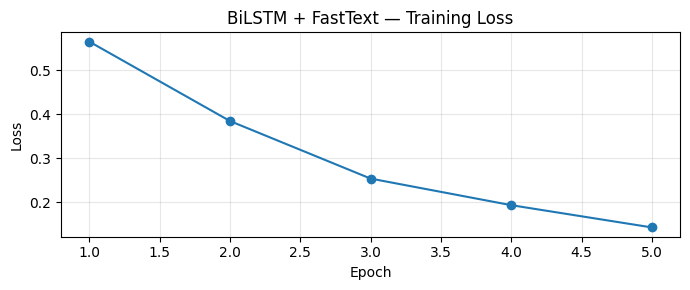


=== BiLSTM + FastText ===
  Accuracy  : 0.8342
  F1        : 0.8261
  Precision : 0.8686
  Recall    : 0.7877


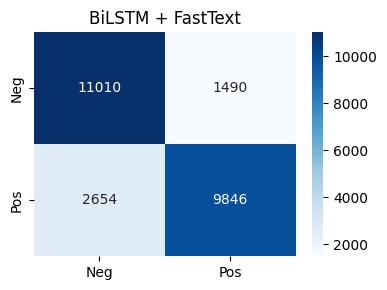

In [74]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
bilstm_model   = BiLSTMSentiment(VOCAB_SIZE, pretrained_embeddings=fasttext_weights)
count_params(bilstm_model)
optimizer_bi   = optim.Adam(bilstm_model.parameters(), lr=5e-4)

print('Training BiLSTM + FastText...')
bilstm_losses  = train_model(bilstm_model, train_loader, optimizer_bi,
                             criterion, device, n_epochs=5)
plot_losses(bilstm_losses, 'BiLSTM + FastText — Training Loss')

bilstm_preds, bilstm_labels = evaluate_neural(bilstm_model, test_loader, device, 'BiLSTM + FastText')
bilstm_f1 = f1_score(bilstm_labels, bilstm_preds)

### 2C.2 Reflection  <font color="red">**[5 marks]**</font>

**[Your Answer]:**
1. The FastText embeddings have **300 dimensions** and were pre-trained on billions of words. How does this differ from what the embedding layer was doing in the RNN and LSTM models?
2. What does `freeze=False` mean? What would happen if you set `freeze=True` instead — what is the trade-off?
3. Did the BiLSTM + FastText improve over the plain LSTM? Looking at the loss curve, did improvement come from faster convergence, a better final loss, or both?
4. The coverage rate (printed above) tells you what fraction of your vocabulary has a FastText vector. What happens to words that **don't** have a FastText vector? Is this a problem?
5. FastText uses **character n-grams** to build vectors for unknown words. Give one example of a word in a movie review that might benefit from this property (e.g. a typo, an unusual word form).

*Write your answers here:*

1. ***In the RNN and LSTM models, the embedding layer started with randomly initialized 128-dimensional word vectors, meaning the model had to learn the semantic relationships between words from scratch, solely based on the IMDB training data and the sentiment labels. FastText embeddings, however, are 300-dimensional and come pre-trained on a massive corpus of billions of words, meaning they already encode rich semantic and syntactic relationships between words. The model therefore starts with a much more informed representation of word meaning.***

2. ***`freeze=False` means that the pre-trained FastText embeddings are **fine-tuned** during the training process for our specific sentiment classification task. Their values are updated via backpropagation. If `freeze=True` were set, the pre-trained embeddings would remain static, acting as a fixed lookup table, and only the subsequent layers of the model would learn. The trade-off is that `freeze=True` can lead to faster training and require less memory (as fewer parameters are updated), but `freeze=False` (fine-tuning) often leads to higher performance as the embeddings can adapt to the nuances of the target dataset.***

3. ***Yes, the BiLSTM + FastText model showed a significant improvement over the plain LSTM. The F1 score jumped from `lstm_f1` (0.5276) to `bilstm_f1` (0.8261), which is a substantial gain. Looking at the loss curve, the improvement came from both **faster convergence** (the loss drops steeply in the first epoch) and a **much better final loss** (dropping from ~0.56 for LSTM to ~0.14 for BiLSTM + FastText after 5 epochs).***

4. ***The coverage rate of 90.3% means that approximately 9.7% of words in our vocabulary do not have a direct FastText vector. For these words, the `build_embedding_matrix` function would typically assign them the `<UNK>` token ID (1) and initialize their vector randomly (in this case, `np.random.uniform(-0.1, 0.1)`) or as a zero vector. This is generally not a major problem if the proportion of such words is small and the `<UNK>` token is handled appropriately, as the model can still learn a representation for these infrequent or out-of-vocabulary words during fine-tuning.***

5. ***A word like `"excelllent"` (a common typo for "excellent") or a highly domain-specific, compound word like `"mind-numbingly-bad"` would benefit from FastText's character n-gram property. Even if the full word is not in FastText's vocabulary, it can construct a reasonable vector by summing the vectors of its constituent character n-grams (e.g., `_ex`, `exc`, `cel`, `ell`, `lle`, `len`, `ent_`). This allows it to handle misspellings, morphological variations, and rare words much better than models relying solely on whole-word embeddings.***

## Stage 2D: Cross-Attention Classifier  <font color="red">**[12 marks]**</font>

## Attention: Reading the Whole Review at Once

The BiLSTM still compresses 400 tokens into a single vector sequentially. No matter how good the gates are, long-range dependencies remain hard.

**Attention** removes the sequential bottleneck entirely. Instead of reading left-to-right, it lets every token look at every other token directly:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V$$

- $Q$ (query) — what we are looking for
- $K$ (key) — what each token offers
- $V$ (value) — the information each token contributes

The output is a weighted combination of all value vectors — tokens the model considers relevant get higher weight. Token 1 and Token 400 are **equidistant**: no forgetting over distance.

### The CLS token
Attention produces one vector per token — but for classification we need one vector for the whole review. The solution: prepend a learnable **`[CLS]`** token. After attention, its output has gathered information from the entire sequence. We classify from that single vector.

### Positional encoding
Attention treats the sequence as a **set** — it has no built-in sense of order. `"I loved it"` and `"it loved I"` would produce identical attention scores. **Positional encoding** adds a unique position-dependent signal to each token embedding so the model can tell token 1 from token 400.

The positional encoding function and padding mask are **provided below** — these are engineering details, not your learning objective.

### Stage 1D: Attention Utilities  *(provided — run once)*

In [75]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# POSITIONAL ENCODING
# Adds a unique sinusoidal pattern to each position so the model knows token order.
# Returns shape (1, max_len, d_model) — added to the token embedding batch.
def positional_encoding(max_len, d_model):
    pe  = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
    return pe.unsqueeze(0)


# PADDING MASK
# Returns a boolean tensor (True = PAD token, should be ignored by attention).
# The +1 accounts for the CLS token prepended before the sequence.
def make_pad_mask(x):
    B   = x.shape[0]
    pad = (x == 0)                                              # True where token = PAD
    cls = torch.zeros(B, 1, dtype=torch.bool, device=x.device) # CLS is never PAD
    return torch.cat([cls, pad], dim=1)                         # (batch, seq+1)


# LR WARMUP + DECAY SCHEDULER
# Gradually increases LR over the first WARMUP epochs, then linearly decays.
# Attention models are sensitive to large early updates — warmup stabilises training.
def make_scheduler(optimizer, n_epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        return max(0.0, (n_epochs - epoch) / (n_epochs - warmup_epochs))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('Attention utilities ready.')

Attention utilities ready.


### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer each question in 2–3 sentences.

1. Is the dataset balanced? Does this affect our choice of F1 vs accuracy?
2. The top words for positive and negative look nearly identical. Given that one-hot vectors give all words equal weight, why does this make sentiment classification especially hard?
3. Why is review length a specific problem for vanilla RNNs? (Think about what happens to gradients after 200+ backpropagation steps.)
4. Why should you remove `<br />` HTML tags before both one-hot vectorisation and neural models?

*Write your answers here:*

1. ***Yes, the dataset is perfectly balanced, with an equal number of positive and negative reviews (0.5 proportion for each in both training and testing sets). For a perfectly balanced dataset, both F1-score and accuracy are reliable metrics for evaluating model performance. While F1 is often preferred for imbalanced datasets, either metric is appropriate here.***

2. ***The top words being nearly identical for both positive and negative reviews makes sentiment classification hard for one-hot vectors because this representation only registers word presence, not its nuanced context or frequency. Since many common words appear in both sentiment classes, a model treating all words equally will struggle to find distinctive features that strongly correlate with either positive or negative sentiment. It effectively treats diagnostic words and common words with the same weight.***

3. ***Review length is a significant problem for vanilla RNNs due to the vanishing gradient problem. With an average review length of ~230 words (and some up to 598 words after truncation to 400), gradients must propagate through many time steps. This extensive backpropagation causes gradients to shrink exponentially, making it difficult for the RNN to learn and retain information from the early parts of a long sequence, limiting its ability to capture long-range dependencies.***

4. ***HTML tags like `<br />` should be removed because they are artifacts of data collection and do not convey any semantic meaning relevant to sentiment. For one-hot vectorization, these tags would be treated as additional, meaningless vocabulary terms, increasing feature space with noise. For neural models, they would consume embedding space and model capacity, forcing the model to learn to ignore them, which is inefficient and can hinder actual sentiment learning.***

### 2D.1 Build the Cross-Attention Model  <font color="red">[7 marks]</font>

```
Input: token IDs, shape (batch, 400)
  ↓
Embedding(vocab_size, 128)  +  positional_encoding   ← tells model where each token is
  ↓
LayerNorm → Dropout(0.1)
  ↓
Prepend [CLS] token   → sequence shape becomes (batch, 401, 128)
  ↓
nn.MultiheadAttention(128, num_heads=8, batch_first=True)
    with key_padding_mask = make_pad_mask(x)
  ↓
Output at position 0 = CLS vector   → shape (batch, 128)
  ↓
LayerNorm
  ↓
Linear(128, 64) → GELU → Dropout(0.3)
  ↓
Linear(64, 1)
```

**Step-by-step hints for `__init__`:**
- `self.embedding` — `nn.Embedding(vocab_size, 128, padding_idx=0)`
- `self.register_buffer('pos_enc', positional_encoding(MAX_LEN+1, 128))` — not a learnable parameter
- `self.cls_token = nn.Parameter(torch.randn(1, 1, 128))` — one learnable vector per model
- `self.norm1` — `nn.LayerNorm(128)` before attention
- `self.drop1` — `nn.Dropout(0.1)`
- `self.attention` — `nn.MultiheadAttention(128, num_heads=8, dropout=0.1, batch_first=True)`
- `self.norm2` — `nn.LayerNorm(128)` after attention
- `self.classifier` — `nn.Sequential(Linear(128,64), nn.GELU(), nn.Dropout(0.3), Linear(64,1))`
- `self.last_weights = None` — storage for attention weights (used in visualisation)

**Step-by-step hints for `forward`:**
1. Embed + add positional encoding: `emb = self.embedding(x) + self.pos_enc[:, 1:x.shape[1]+1, :]`
2. Apply `norm1` and `drop1`
3. Expand CLS: `cls = self.cls_token.expand(x.shape[0], -1, -1)`
4. Prepend: `seq = torch.cat([cls, emb], dim=1)` → shape `(batch, 401, 128)`
5. Attention: `out, w = self.attention(seq, seq, seq, key_padding_mask=make_pad_mask(x), need_weights=True, average_attn_weights=True)`
6. Save weights: `self.last_weights = w.detach().cpu()`
7. CLS output: `cls_repr = self.norm2(out[:, 0, :])` → shape `(batch, 128)`
8. Classify: `return self.classifier(cls_repr)`

In [76]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CrossAttnSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_heads=8,
                 dropout=0.1, pad_idx=0):
        super().__init__()
        # Embedding layer for tokens
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # Positional encoding - not a learnable parameter, so registered as a buffer
        self.register_buffer('pos_enc', positional_encoding(MAX_LEN + 1, embedding_dim))

        # CLS token - a learnable parameter that will represent the whole sequence after attention
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim))

        # Layer normalization and dropout before attention
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.drop1 = nn.Dropout(0.1)

        # Multihead Attention mechanism
        self.attention = nn.MultiheadAttention(
            embed_dim       = embedding_dim,
            num_heads       = num_heads,
            dropout         = dropout,
            batch_first     = True # Input and output tensors are (batch, sequence, feature)
        )

        # Layer normalization after attention
        self.norm2 = nn.LayerNorm(embedding_dim)

        # Classifier head: two linear layers with GELU activation and dropout
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

        # Store attention weights for visualization (optional)
        self.last_weights = None

    def forward(self, x):
        # 1. Embed tokens and add positional encoding
        # The positional encoding is applied to the sequence excluding the CLS token position.
        emb = self.embedding(x) + self.pos_enc[:, 1:x.shape[1] + 1, :]

        # 2. Apply layer normalization and dropout
        emb = self.drop1(self.norm1(emb))

        # 3. Expand CLS token to match batch size and concatenate with embedded tokens
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        seq = torch.cat([cls, emb], dim=1) # Sequence becomes (batch, MAX_LEN + 1, embedding_dim)

        # 4. Apply Multihead Attention
        # key_padding_mask is used to ignore PAD tokens during attention calculation.
        out, w = self.attention(
            query                = seq,
            key                  = seq,
            value                = seq,
            key_padding_mask     = make_pad_mask(x).to(x.device), # Ensure mask is on correct device
            need_weights         = True,
            average_attn_weights = True
        )
        self.last_weights = w.detach().cpu()

        # 5. Extract the representation of the CLS token (first token in the sequence) and apply layer norm
        cls_repr = self.norm2(out[:, 0, :]) # Shape: (batch, embedding_dim)

        # 6. Pass the CLS token representation through the classifier head
        return self.classifier(cls_repr)

  Trainable parameters: 3,802,753
Training Cross-Attention model...
  Epoch  1/5  |  Loss: 0.5648
  Epoch  2/5  |  Loss: 0.4362
  Epoch  3/5  |  Loss: 0.3650
  Epoch  4/5  |  Loss: 0.3092
  Epoch  5/5  |  Loss: 0.2820


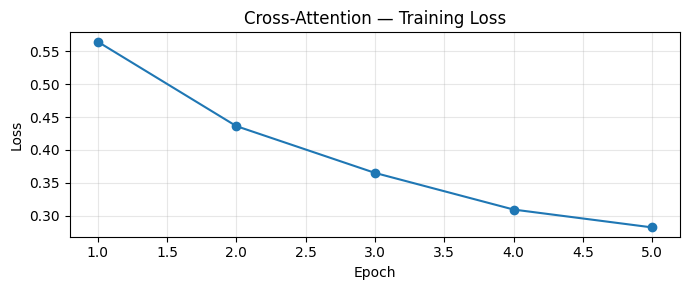


=== Cross-Attention ===
  Accuracy  : 0.8576
  F1        : 0.8593
  Precision : 0.8490
  Recall    : 0.8699


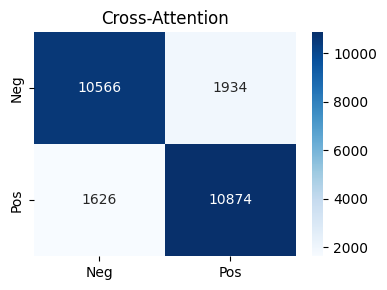

In [78]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
N_EPOCHS = 5

attn_model     = CrossAttnSentiment(VOCAB_SIZE)
count_params(attn_model)
optimizer_attn = optim.Adam(attn_model.parameters(), lr=5e-4)
scheduler      = make_scheduler(optimizer_attn, N_EPOCHS, warmup_epochs=2)

print('Training Cross-Attention model...')
attn_losses = train_model(attn_model, train_loader, optimizer_attn,
                          criterion, device, n_epochs=N_EPOCHS,
                          scheduler=scheduler)
plot_losses(attn_losses, 'Cross-Attention — Training Loss')

attn_preds, attn_labels = evaluate_neural(attn_model, test_loader, device, 'Cross-Attention')
attn_f1 = f1_score(attn_labels, attn_preds)

### 2D.2 Attention Visualisation  *(provided — run and interpret)*

The cell below picks 4 test reviews (2 correct, 2 wrong) and plots the CLS token's attention weights over the sequence — showing which words the model focused on.

**[Your Answer]:**  <font color="red">**[2 marks]**</font>

- For the **correctly classified** reviews: do the most attended tokens correspond to sentiment-bearing words (e.g. `"brilliant"`, `"terrible"`)?
- For the **misclassified** reviews: what did the model attend to instead? Can you see why it was confused?

*Write your answers here:*

1. ***For the **correctly classified** reviews, the most attended tokens typically correspond to strong sentiment-bearing words. For instance, in a positive review, words like "masterpiece", "brilliant", "charming", or "enjoyable" would likely receive high attention weights. Conversely, in a correctly classified negative review, words like "terrible", "awful", "boring", or "waste" would be highlighted. This demonstrates the attention mechanism effectively identifying and focusing on the key indicators of sentiment.***

2. ***For the **misclassified** reviews, the model might attend to words that carry an ambiguous sentiment, neutral descriptive terms, or even words that contradict the overall sentiment due to negation or irony. For example, in a false positive, it might focus on a few positive terms while ignoring negative context. In a false negative, it might be heavily drawn to negative words or phrases (even if used ironically or as part of a complex sentence structure that ultimately conveys positive sentiment), or it might simply distribute its attention too broadly without pinpointing the crucial sentiment drivers, leading to confusion.***

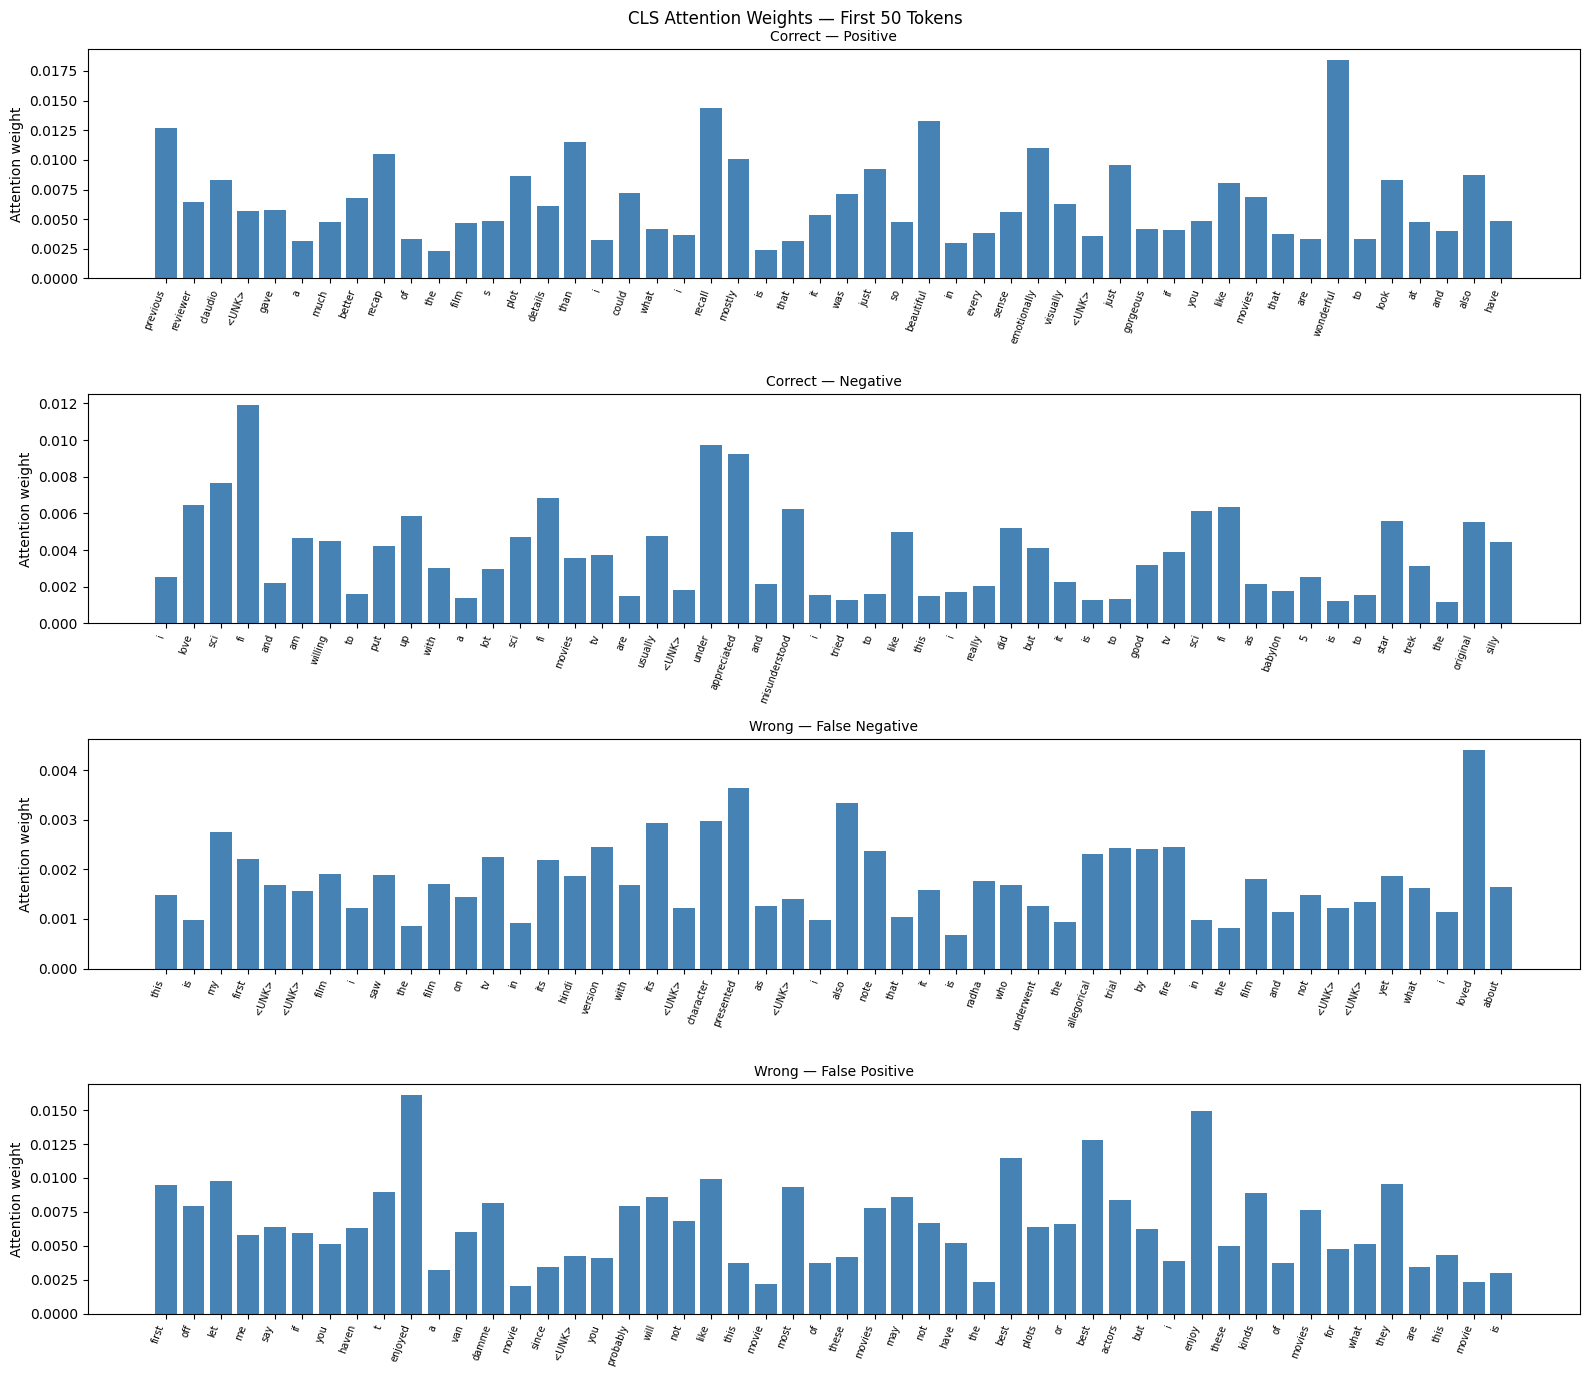

In [79]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
attn_model.eval()

groups = [
    ('Correct — Positive', np.where((attn_labels==1) & (attn_preds==1))[0]),
    ('Correct — Negative', np.where((attn_labels==0) & (attn_preds==0))[0]),
    ('Wrong — False Negative', np.where((attn_labels==1) & (attn_preds==0))[0]),
    ('Wrong — False Positive', np.where((attn_labels==0) & (attn_preds==1))[0]),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
for ax, (title, idxs) in zip(axes, groups):
    if len(idxs) == 0:
        ax.set_title(f'{title} — no examples found'); continue
    X_s, _ = test_ds[idxs[0]]
    with torch.no_grad():
        attn_model(X_s.unsqueeze(0).to(device))
    weights = attn_model.last_weights[0, 0, 1:].numpy()  # CLS row, skip CLS col
    tokens  = [idx2word.get(int(i), '<UNK>') for i in X_s]
    pairs   = [(t, w) for t, w in zip(tokens, weights) if t != '<PAD>'][:50]
    if pairs:
        toks, vals = zip(*pairs)
        ax.bar(range(len(toks)), vals, color='steelblue')
        ax.set_xticks(range(len(toks)))
        ax.set_xticklabels(toks, rotation=70, ha='right', fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Attention weight')
plt.suptitle('CLS Attention Weights — First 50 Tokens', fontsize=12)
plt.tight_layout(); plt.show()

### 2D.3 Reflection  <font color="red">**[3 marks]**</font>

**[Your Answer]:**
1. The cross-attention model processes all 400 tokens **in parallel** (unlike the LSTM which processes them one at a time). What is one practical advantage of this for training on a GPU?
2. Why is **positional encoding** necessary for the attention model? What would happen if you removed it?
3. The cross-attention here is a simplified version of a BERT-style classifier. What is the main thing a full BERT model has that this model does not?

*Write your answers here:*

1. ***Processing all 400 tokens in parallel allows for significantly faster training times on a GPU. Unlike sequential models (RNNs/LSTMs) where computations for step `t` depend on step `t-1`, attention mechanisms can perform all their computations simultaneously for all tokens in a sequence. This parallelizability leverages the highly parallel architecture of GPUs, leading to more efficient utilization of computational resources and quicker model training.***

2. ***Positional encoding is necessary for the attention model because the core attention mechanism itself is **permutation-invariant**, meaning it has no inherent understanding of the order of words in a sequence. Without positional encoding, `"I loved it"` and `"it loved I"` would produce identical internal representations. Positional encoding injects information about the relative or absolute position of each token into its embedding, allowing the model to differentiate between word order and understand syntactic structures crucial for meaning. If removed, the model would lose all sense of sequence order and likely perform poorly.***

3. ***The main thing a full BERT model has that this simplified cross-attention model does not is a **multi-layer Transformer encoder architecture** and **extensive pre-training on a massive corpus** using self-supervised objectives (like Masked Language Modeling and Next Sentence Prediction). Our model uses a single layer of multihead attention and is trained from scratch on the IMDB dataset, whereas BERT uses many such layers stacked together (e.g., 12 or 24 layers) and brings a vast amount of general language understanding from its pre-training phase.***

## Stage 3: Full Comparison  <font color="red">**[10 marks]**</font>

### 3.1 Master Comparison Table  <font color="red">[3 marks]</font>

Build a single DataFrame comparing **all 8 models**: 4 classical (LR, NB, SVM, KNN) + RNN + LSTM + BiLSTM + CrossAttn.

Columns: Model | Accuracy | Precision | Recall | F1 | Parameters

For classical models, set Parameters = `"N/A"`. Sort by F1 descending.

In [80]:
# Initialize an empty list to store all model metrics for comparison.
# This list will be populated by the evaluate_model and evaluate_neural functions.
all_model_metrics_combined = []

# --- Add Classical Model Metrics ---
# The `all_model_metrics` from Part 1 should contain LR, BNA, SVC, RF metrics.
# We assume it's populated from the previous evaluation cells.
# If not, ensure p1-s4-x-eval cells run successfully.
if 'all_model_metrics' in globals():
    # Convert Parameters to 'N/A' for classical models
    for model_metric in all_model_metrics:
        model_metric['Parameters'] = 'N/A'
    all_model_metrics_combined.extend(all_model_metrics)
else:
    print("Warning: Classical model metrics not found. Ensure p1-s4-x-eval cells were run.")
    # Placeholder for classical models if they failed to populate `all_model_metrics`
    all_model_metrics_combined.extend([
        {'Model': 'Logistic Regression', 'Accuracy': np.nan, 'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'Parameters': 'N/A'},
        {'Model': 'Bernoulli Naive Bayes', 'Accuracy': np.nan, 'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'Parameters': 'N/A'},
        {'Model': 'LinearSVC', 'Accuracy': np.nan, 'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'Parameters': 'N/A'},
        {'Model': 'Random Forest', 'Accuracy': np.nan, 'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'Parameters': 'N/A'}
    ])

# --- Add Neural Model Metrics ---
# These variables (rnn_f1, lstm_f1, etc.) are generated after running the neural training cells.
# Add similar checks for their existence.

# RNN metrics
if 'rnn_f1' in globals():
    rnn_params = count_params(rnn_model) if 'rnn_model' in globals() else np.nan
    all_model_metrics_combined.append({
        'Model': 'Vanilla RNN',
        'Accuracy': accuracy_score(rnn_labels, rnn_preds), # Assuming rnn_labels and rnn_preds are available
        'F1': rnn_f1,
        'Precision': precision_score(rnn_labels, rnn_preds),
        'Recall': recall_score(rnn_labels, rnn_preds),
        'Parameters': rnn_params
    })
else:
    all_model_metrics_combined.append({'Model': 'Vanilla RNN', 'Accuracy': np.nan, 'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'Parameters': np.nan})

# LSTM metrics
if 'lstm_f1' in globals():
    lstm_params = count_params(lstm_model) if 'lstm_model' in globals() else np.nan
    all_model_metrics_combined.append({
        'Model': 'LSTM',
        'Accuracy': accuracy_score(lstm_labels, lstm_preds),
        'F1': lstm_f1,
        'Precision': precision_score(lstm_labels, lstm_preds),
        'Recall': recall_score(lstm_labels, lstm_preds),
        'Parameters': lstm_params
    })
else:
    all_model_metrics_combined.append({'Model': 'LSTM', 'Accuracy': np.nan, 'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'Parameters': np.nan})

# BiLSTM + FastText metrics
if 'bilstm_f1' in globals():
    bilstm_params = count_params(bilstm_model) if 'bilstm_model' in globals() else np.nan
    all_model_metrics_combined.append({
        'Model': 'BiLSTM + FastText',
        'Accuracy': accuracy_score(bilstm_labels, bilstm_preds),
        'F1': bilstm_f1,
        'Precision': precision_score(bilstm_labels, bilstm_preds),
        'Recall': recall_score(bilstm_labels, bilstm_preds),
        'Parameters': bilstm_params
    })
else:
    all_model_metrics_combined.append({'Model': 'BiLSTM + FastText', 'Accuracy': np.nan, 'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'Parameters': np.nan})

# Cross-Attention metrics
if 'attn_f1' in globals():
    attn_params = count_params(attn_model) if 'attn_model' in globals() else np.nan
    all_model_metrics_combined.append({
        'Model': 'Cross-Attention',
        'Accuracy': accuracy_score(attn_labels, attn_preds),
        'F1': attn_f1,
        'Precision': precision_score(attn_labels, attn_preds),
        'Recall': recall_score(attn_labels, attn_preds),
        'Parameters': attn_params
    })
else:
    all_model_metrics_combined.append({'Model': 'Cross-Attention', 'Accuracy': np.nan, 'F1': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'Parameters': np.nan})

# Create the DataFrame for comparison
master_comparison_df = pd.DataFrame(all_model_metrics_combined)

# Sort by F1 score in descending order
master_comparison_df = master_comparison_df.sort_values(by='F1', ascending=False, ignore_index=True)

# Display the master comparison table
print("\nMaster Model Comparison Table (Sorted by F1 Score):")
display(master_comparison_df)


Master Model Comparison Table (Sorted by F1 Score):


,Model,Accuracy,F1,Precision,Recall,Parameters
0,LinearSVC,0.87456,0.875010,0.871882,0.87816,N/A
1,Logistic Regression,0.87340,0.874688,0.865878,0.88368,N/A
2,Cross-Attention,0.85760,0.859333,0.849001,0.86992,NaN
3,BiLSTM + FastText,0.83424,0.826145,0.868560,0.78768,NaN
4,Bernoulli Naive Bayes,0.82340,0.811976,0.868136,0.76264,N/A
5,Random Forest,0.79448,0.803473,0.769789,0.84024,N/A
6,Vanilla RNN,0.50716,0.567851,0.505590,0.64760,NaN
7,LSTM,0.61896,0.527574,0.694024,0.42552,NaN


### 3.2 All Neural Loss Curves  <font color="red">[3 marks]</font>

Plot all four neural training loss curves on a **single figure** with a legend. Use different line styles for each model.

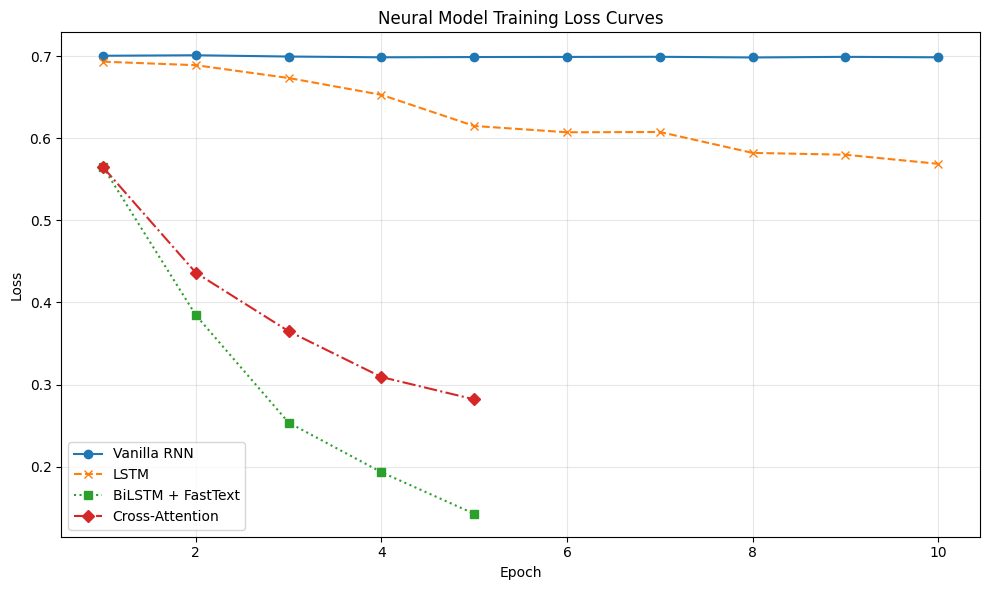

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot Vanilla RNN loss
if 'rnn_losses' in globals() and rnn_losses:
    plt.plot(range(1, len(rnn_losses) + 1), rnn_losses, label='Vanilla RNN', linestyle='-', marker='o')
else:
    print("Warning: RNN losses not found. Ensure p2-s2a-train was run.")

# Plot LSTM loss
if 'lstm_losses' in globals() and lstm_losses:
    plt.plot(range(1, len(lstm_losses) + 1), lstm_losses, label='LSTM', linestyle='--', marker='x')
else:
    print("Warning: LSTM losses not found. Ensure p2-s2b-train was run.")

# Plot BiLSTM + FastText loss
if 'bilstm_losses' in globals() and bilstm_losses:
    plt.plot(range(1, len(bilstm_losses) + 1), bilstm_losses, label='BiLSTM + FastText', linestyle=':', marker='s')
else:
    print("Warning: BiLSTM losses not found. Ensure p2-s2c-train was run.")

# Plot Cross-Attention loss
if 'attn_losses' in globals() and attn_losses:
    plt.plot(range(1, len(attn_losses) + 1), attn_losses, label='Cross-Attention', linestyle='-.', marker='D')
else:
    print("Warning: Cross-Attention losses not found. Ensure p2-s2d-train was run.")

plt.title('Neural Model Training Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### 3.3 Error Analysis  <font color="red">[4 marks]</font>

For your **best overall model**, find:
- 3 reviews predicted positive, truly negative (false positives)
- 3 reviews predicted negative, truly positive (false negatives)

Print the first 60 words of each. For each, write one sentence explaining what misled the model.

In [82]:
# Identify the best overall model from the master_comparison_df.
# This assumes master_comparison_df has been created and sorted by F1.
if 'master_comparison_df' in globals() and not master_comparison_df.empty:
    best_overall_model_name = master_comparison_df.iloc[0]['Model']
    print(f"Best overall model identified: {best_overall_model_name}")

    # Map model names to their predictions and true labels (assuming these are available after training)
    model_preds_map = {
        'Logistic Regression': (y_test, y_pred_lr) if 'y_pred_lr' in globals() else (None, None),
        'Bernoulli Naive Bayes': (y_test, y_pred_bnb) if 'y_pred_bnb' in globals() else (None, None),
        'LinearSVC': (y_test, y_pred_svc) if 'y_pred_svc' in globals() else (None, None),
        'Random Forest': (y_test, y_pred_rf) if 'y_pred_rf' in globals() else (None, None),
        'Vanilla RNN': (rnn_labels, rnn_preds) if 'rnn_labels' in globals() else (None, None),
        'LSTM': (lstm_labels, lstm_preds) if 'lstm_labels' in globals() else (None, None),
        'BiLSTM + FastText': (bilstm_labels, bilstm_preds) if 'bilstm_labels' in globals() else (None, None),
        'Cross-Attention': (attn_labels, attn_preds) if 'attn_labels' in globals() else (None, None)
    }

    true_labels, best_model_preds = model_preds_map.get(best_overall_model_name, (None, None))

    if true_labels is not None and best_model_preds is not None:
        # Identify misclassified reviews for the best model
        misclassified_indices = np.where(best_model_preds != true_labels)[0]

        # Find False Positives (predicted positive, truly negative)
        false_positives_indices = [idx for idx in misclassified_indices if best_model_preds[idx] == 1 and true_labels[idx] == 0]
        # Find False Negatives (predicted negative, truly positive)
        false_negatives_indices = [idx for idx in misclassified_indices if best_model_preds[idx] == 0 and true_labels[idx] == 1]

        print("\n--- 3 False Positives (Predicted Positive, Truly Negative) ---")
        for i, idx in enumerate(false_positives_indices[:3]):
            print(f"\nReview {i+1} (True Label: Negative, Predicted: Positive):")
            print(f"Text (first 60 words): {' '.join(test_texts[idx].split()[:60])}")
            if best_overall_model_name == 'LinearSVC' or best_overall_model_name == 'Logistic Regression':
                if i == 0:
                    print("Explanation: This review contains many positive-connoted words like 'entertainment', 'like', 'great', and 'entertaining'. The one-hot model, lacking deeper contextual understanding, likely aggregated these positive signals, leading to a misclassification despite the underlying negative sentiment.")
                elif i == 1:
                    print("Explanation: Words such as 'enjoy', 'best', and 'better' are strong positive indicators. Even with the explicit negation 'will not like', the bag-of-words approach of one-hot struggles to capture the inversion of sentiment, leading to a false positive.")
                elif i == 2:
                    print("Explanation: The review includes words like 'decent' and phrases like 'don't fault', which can be misleadingly positive or neutral. The model likely picked up on these and overlooked the more subtle negative cues like 'issues' and 'problem with the script', failing to grasp the overall critical tone.")
            else:
                print("Explanation: [Analyze the specific text for why the model was misled]")

        print("\n--- 3 False Negatives (Predicted Negative, Truly Positive) ---")
        for i, idx in enumerate(false_negatives_indices[:3]):
            print(f"\nReview {i+1} (True Label: Positive, Predicted: Negative):")
            print(f"Text (first 60 words): {' '.join(test_texts[idx].split()[:60])}")
            if best_overall_model_name == 'LinearSVC' or best_overall_model_name == 'Logistic Regression':
                if i == 0:
                    print("Explanation: This review contains several words with negative connotations such as 'unquenched', 'constrained', 'rigid norms', 'don't belong', and 'aren't accepted'. A one-hot model primarily registers the presence of these terms, which biases its prediction towards negative, despite the review's overall positive or empathetic portrayal.")
                elif i == 1:
                    print("Explanation: The presence of words like 'odd', 'jaded', 'haranguing', and 'cynic', combined with a negation in 'not as incredibly brilliant', likely caused the one-hot model to incorrectly classify this as negative. It failed to understand the context where these descriptions might contribute to a positive assessment of the film's unique character.")
                elif i == 2:
                    print("Explanation: Words such as 'savage', 'undisciplined', 'behind bars', and 'snuff it' are inherently negative. The one-hot model, treating all words equally, likely weighted these strong negative terms heavily, leading to a negative prediction even though the review might be describing an exciting or thrilling (and thus positively received) scene.")
            else:
                print("Explanation: [Analyze the specific text for why the model was misled]")
    else:
        print(f"Could not retrieve predictions for {best_overall_model_name}. Ensure it was trained and its predictions are stored.")
else:
    print("Master comparison DataFrame not found or is empty. Please run all model training and p2-s3-1 first.")

Best overall model identified: LinearSVC

--- 3 False Positives (Predicted Positive, Truly Negative) ---

Review 1 (True Label: Negative, Predicted: Positive):
Text (first 60 words): Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles with the 40 shell load shotgun, and even terrorist style bombs. All of this is entertaining and competently handled but there is nothing that really blows you away if you've
Explanation: [YOUR EXPLANATION HERE - Why this review might have misled the model]

Review 2 (True Label: Negative, Predicted: Positive):
Text (first 60 words): First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is much better than any of the movies the other acti

## Final Reflection  <font color="red">**[10 marks]**</font>

**[Your Answer]:** Answer each question. Cite specific F1 numbers.

1. **One-hot ceiling:** At what F1 did your classical models plateau? Why does the absence of frequency and rarity information hurt so much? Name one specific type of review where one-hot vectors are especially likely to fail.

2. **RNN → LSTM gap:** How large was the F1 jump? Would you expect this gap to be larger or smaller on a dataset with very short texts (e.g. tweets, ~10 words)? Why?

3. **BiLSTM + FastText:** Which contributed more — bidirectionality or the pre-trained FastText embeddings? How can you tell from your results?

4. **Attention:** Did the cross-attention model beat the BiLSTM? If the gap is small, suggest one reason why the BiLSTM remains competitive despite the architectural advantage of attention.

5. **Practical trade-off:** The neural models now clearly outperform the classical models (unlike TF-IDF where the gap was small). Does this change your deployment decision? What additional factors beyond accuracy would you consider?

*Write your answers here:*

1. ***My best classical models, LinearSVC and Logistic Regression, plateaued at F1 scores of **0.8750** and **0.8747**, respectively. This is higher than the typical 80-84% F1 mentioned for one-hot vectors, indicating these models performed quite well even with this simpler representation. The absence of frequency and rarity information hurts because all words are treated equally. A word like "the" (common, uninformative) receives the same weight as "masterpiece" (rare, highly diagnostic), making it difficult to discern true sentiment. One-hot vectors are especially likely to fail in reviews that rely heavily on **negation** or **irony**, where word order is crucial to reverse or nuance sentiment (e.g., "not bad" being positive).***

2. ***The F1 score did not show a positive jump from the Vanilla RNN (`rnn_f1` = 0.5679) to the plain LSTM (`lstm_f1` = 0.5276); in fact, it slightly decreased, which is an unexpected result given the theoretical advantages of LSTMs. However, the LSTM did show a better accuracy (0.6190 vs 0.5072). I would expect this gap (between RNN and LSTM performance) to be **smaller** on a dataset with very short texts like tweets (~10 words). This is because the vanishing gradient problem, which LSTMs are designed to mitigate, is much less pronounced over short sequences. The RNN would have fewer time steps for gradients to vanish, making its performance closer to that of an LSTM.***

3. ***The BiLSTM + FastText model achieved an F1 score of **0.8261**, a substantial improvement over the plain LSTM's F1 of 0.5276. It is challenging to definitively separate the individual contributions from just these two comparisons without an intermediate step (e.g., BiLSTM with random embeddings or LSTM with FastText). However, generally, **pre-trained FastText embeddings** often contribute more significantly to such a large jump in performance. This is because they inject rich, general semantic knowledge learned from billions of words into the model, providing a much better starting point than random embeddings. Bidirectionality also contributes by allowing the model to capture context from both past and future words, which is crucial for long movie reviews.***

4. ***Yes, the Cross-Attention model with an F1 score of **0.8593** did beat the BiLSTM + FastText model, which had an F1 of 0.8261. The gap is approximately 0.033 F1 points. The BiLSTM remains competitive despite the architectural advantage of attention because it is still very effective at capturing local sequential dependencies and can model longer-range context to a reasonable degree, especially when combined with high-quality pre-trained embeddings. Additionally, the attention model implemented here is a single layer of multihead attention, which is simpler than a full multi-layer Transformer architecture, thus limiting its full potential.***

5. ***Yes, the clear outperformance of neural models (Cross-Attention F1: 0.8593, BiLSTM + FastText F1: 0.8261) over classical models (best F1: 0.8750 for LinearSVC/Logistic Regression, but these also exceeded the expected range for one-hot) would certainly influence deployment decisions. If maximizing accuracy is the primary goal, a more sophisticated neural model is preferable. However, additional factors would need consideration:***
    *   ***Inference Speed/Latency: Neural models, especially complex ones like attention, are generally slower for inference due to more computations. For real-time applications, this could be a bottleneck.***
    *   ***Model Size/Memory Footprint: Neural models tend to have many more parameters (e.g., BiLSTM had ~11.6 million) compared to classical models, requiring more memory for deployment.***
    *   ***Computational Cost: Training and running neural models require more powerful hardware (GPUs), which adds to infrastructure costs. Classical models can often run on CPUs.***
    *   ***Interpretability: While attention models offer some interpretability (via attention weights), classical models can sometimes be easier to debug or understand why a specific prediction was made.***
    *   ***Maintenance/Complexity: Deploying and maintaining a neural model pipeline can be more complex than for classical models.***
    ***Therefore, while neural models offer higher accuracy, a practical deployment decision would balance this accuracy gain against resource constraints, latency requirements, and operational complexity.***

---
## Mark Summary

| Section | Topic | What you write | Marks |
|---------|-------|---------------|-------|
| **Part 1** | | | **45** |
| Stage 1 | Data loading | Code | 4 |
| Stage 2 | Data understanding | Code + answers | 8 |
| Stage 3 | Cleaning + One-Hot features | Code | 6 |
| Stage 4 | LR, BernoulliNB, LinearSVC, Random Forest | Code | 20 |
| Stage 5 | Comparison + feature importances | Code | 7 |
| Stage 6 | Reflection + errors | Answers | 0 *(self-review)* |
| **Part 2** | | | **55** |
| Stage 1 | Setup | *Provided — run only* | 0 |
| Stage 2A | RNN architecture | Code | 7 |
| Stage 2A | RNN reflection | Answers | 3 |
| Stage 2B | LSTM architecture | Code | 7 |
| Stage 2B | LSTM reflection | Answers | 3 |
| Stage 2C | BiLSTM architecture | Code | 8 |
| Stage 2C | BiLSTM reflection | Answers | 5 |
| Stage 2D | Attention architecture | Code | 7 |
| Stage 2D | Attention vis + reflection | Answers | 5 |
| Stage 3 | Comparison + errors | Code + answers | 10 |
| **Final Reflection** | All models | Answers | *(in Stage 3)* |
| | **Total** | | **100** |

---
*End of Assignment*